# Entanglement swapping and superdense coding

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 8 — Quantum information protocols*

## 1. Introduction and motivation

Teleportation ([notebook 20](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb)) showed that one shared Bell
pair, one **ebit**, together with two classical bits can stand in for one transmitted qubit. This notebook follows that
bookkeeping further and treats entanglement as a **resource that is distributed in advance, spent by protocols, and traded for
other resources**. Two protocols make the trade concrete.

**Entanglement swapping.** Alice and Bob may be too far apart to share a pair directly: photons sent through an optical fibre are
lost exponentially with distance, and no-cloning forbids amplifying them. A relay, Charlie, therefore stands in the middle.
Alice's qubit $0$ is entangled with qubit $1$ at the relay; a second, completely independent pair consists of qubit $2$ at the
relay and qubit $3$ at Bob's. Qubits $0$ and $3$ have never interacted and are described by a state that contains no correlation
whatsoever. Charlie then performs a **Bell measurement**, a joint measurement in the basis of the four Bell states, on qubits $1$
and $2$ — and afterwards $0$ and $3$ are in a maximally entangled state. Nothing travelled between the two outer qubits except a
two-bit classical message saying which of four outcomes occurred. The idea is due to Żukowski, Zeilinger, Horne and Ekert (1993),
was demonstrated with photons by Pan and co-workers (1998), and is the elementary step of a **quantum repeater**, the standard
proposal for distributing entanglement through optical fibre over distances much larger than its attenuation length (the distance over
which the transmission of the fibre falls by a factor $e$).

**Superdense coding.** Alice and Bob share one ebit, prepared long ago. Alice now wants to send Bob two classical bits. She
applies one of four Pauli gates to *her half of the pair*, physically sends that one qubit to Bob, and Bob, with a Bell
measurement on the two qubits, recovers both bits with certainty. One qubit carried two bits. Without the shared pair this is
impossible: the Holevo bound says a $d$-dimensional quantum system carries at most $\log_2 d$ bits, so one qubit alone carries at
most one. The protocol is due to Bennett and Wiesner (1992) and was realised with photons by Mattle, Weinfurter, Kwiat and
Zeilinger (1996).

In resource language the two transmission protocols are mirror images: teleportation turns $1$ ebit $+$ $2$ classical bits into
$1$ transmitted qubit, superdense coding turns $1$ ebit $+$ $1$ transmitted qubit into $2$ classical bits, and swapping turns two
short ebits into one long one. All three consist of the same three ingredients: a shared Bell pair, a Bell measurement, and a
**Pauli correction chosen by a classical message**. Once one of them has been understood in full algebraic detail, the others cost
almost nothing.

**Road map.**

1. Recall the Bell basis and the four Pauli relations that connect its elements (Section 3).
2. Rewrite the four-qubit state $\vert\Phi^+\rangle_{01}\otimes\vert\Phi^+\rangle_{23}$ in the Bell basis *of the middle pair*
   $(1,2)$. The result, Eq. (5), contains the whole protocol (Section 4).
3. Implement it with the einsum engine: the state, the Bell-measurement circuit, the four conditional outer states, and the
   corrections (Sections 5–6).
4. Measure the entanglement of the outer pair **before** the measurement, **after** it conditioned on each outcome, and after it
   **without** knowing the outcome — three different answers, and the difference between them is exactly the value of the
   classical message (Sections 7–8).
5. Run the protocol as a real device would: a mid-circuit measurement with a `jnp.where` feed-forward, `jit`-compiled and
   `vmap`-ed over thousands of shots, with error bars on the outcome frequencies (Section 9).
6. Replace the perfect links by **Werner states** of parameter $W$ (Bell pairs mixed with white noise) and prove — then verify on
   the density tensor — that swapping multiplies the parameters, $W_{\text{out}}=W_1W_2$. Iterate over a chain of $n$ links, watch
   $W$ collapse like $W^n$, and understand why entanglement *purification*, which distils fewer but better pairs from many noisy
   ones, is not optional (Sections 10–11).
7. Turn to superdense coding: protocol, algebra, decoding circuit, perfect statistics for all four messages, the Holevo bound, and
   the confusion matrix (sent against decoded message) and the transmission rate when the shared pair is depolarised or dephased
   (Sections 12–17).

### What you will learn

*Physics*

* what a Bell measurement is, why it has four outcomes, and why each of them occurs with probability $1/4$ whenever the two
  relay qubits are each maximally mixed (and with other probabilities when they are not);
* that entanglement can be created between particles that never interacted, and that this does **not** transmit information —
  the outer pair is maximally mixed until the classical message arrives;
* the resource arithmetic of quantum communication: $1$ ebit $+$ $2$ classical bits $\to$ $1$ qubit (teleportation),
  $1$ ebit $+$ $1$ qubit $\to$ $2$ classical bits (superdense coding);
* Werner/isotropic states, the entanglement threshold $W>1/3$, and the multiplicative degradation of a repeater chain;
* the Holevo bound and why superdense coding does not violate it.

*Numerical methods*

* mid-circuit projective measurement on a state vector and on a density tensor (projector, Born probability, renormalisation);
* negativity via the partial transpose and Wootters' concurrence via the spin-flipped matrix;
* Bell-diagonal states as *random Pauli errors* applied to $\vert\Phi^+\rangle$, and group convolution of error distributions;
* reading a confusion matrix: decoding error probability, mutual information, and the difference between the rate of a fixed
  protocol and the capacity of the resource it uses.

*Implementation practice*

* feed-forward without Python branching: `jnp.where` selects the correction matrix, so the whole protocol stays inside one
  `jax.jit` and can be `vmap`-ed over shots;
* explicit PRNG keys split deterministically — the notebook reproduces exactly;
* two independent implementations of the same physics (projection of a pure state vs. Kraus/projection on a density tensor) used
  as a checkpoint against each other;
* binomial error bars on measured frequencies, and the discipline of never quoting a number the code did not print.

### Prerequisites
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys, `jnp.where`;
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation as executable code;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb): reduced density
  matrices, Schmidt decomposition;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, partial trace, Kraus channels, fidelity;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, collapse, sampling;
* [19 — Bell states and CHSH](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb): the Bell basis and its
  correlations — we use them here, we do not re-derive them;
* [20 — quantum teleportation](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb): the Bell measurement and the
  classical feed-forward in their original setting.

**Conventions.** Qubit $q$ = tensor axis $q$, counted from $0$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; a measurement result
$o\in\{0,1\}$ means the eigenvalue $(-1)^{o}$; the leftmost symbol of a ket is qubit $0$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We need the einsum primitives (`apply_gate` for state vectors, `apply_gate_dm` and `apply_kraus_dm` for density tensors), the
reduced density matrices, the entanglement negativity through the partial transpose, and the standard channels. Everything that is
specific to these two protocols is written from scratch below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def dm_tensor(mat, N):
    """Inverse of `dm_matrix`: view a 2^N x 2^N matrix as a rank-2N density tensor (ket axes 0..N-1, bra axes N..2N-1)."""
    return jnp.asarray(mat, dtype=CDTYPE).reshape((2,) * (2 * N))


def neg2(rho_mat):
    """Entanglement negativity of a TWO-qubit density matrix (4x4), qubit 0 vs qubit 1.

    MATH   N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues of rho^{T_A}|.
           For 2x2 systems the Peres-Horodecki criterion is necessary AND sufficient:
           N > 0  <=>  the state is entangled.  Maximally entangled (Bell) state: N = 1/2.
    """
    return float(negativity(dm_tensor(rho_mat, 2), [0])[0])


def concurrence(rho_mat):
    """Wootters' concurrence of a TWO-qubit density matrix (Phys. Rev. Lett. 80, 2245 (1998)).

    MATH   spin-flipped state   rho~ = (Y (x) Y) rho^* (Y (x) Y)
           lambda_1 >= ... >= lambda_4 = square roots of the eigenvalues of rho rho~
           C(rho) = max(0, lambda_1 - lambda_2 - lambda_3 - lambda_4).
           Pure product state: C = 0.  Bell state: C = 1.  (An entanglement measure for two qubits:
           the entanglement of formation is a monotone function of C.)
    IMPLEMENTATION  rho rho~ is not Hermitian, so instead of a general eigenvalue problem we use the
           Hermitian form sqrt(rho) rho~ sqrt(rho).  With A = sqrt(rho) and B = sqrt(rho) rho~ we have
           rho rho~ = AB and sqrt(rho) rho~ sqrt(rho) = BA, and AB, BA have the SAME eigenvalues (also
           for singular rho); they are real and non-negative, so `eigvalsh` applies.
    """
    YY_ = jnp.kron(Y, Y)
    rho_mat = jnp.asarray(rho_mat, dtype=CDTYPE)
    rho_tilde = YY_ @ jnp.conj(rho_mat) @ YY_
    s = _sqrtm_psd(rho_mat)
    lam = jnp.sqrt(jnp.clip(jnp.linalg.eigvalsh(s @ rho_tilde @ s), 0.0, None))   # ascending
    return float(jnp.maximum(0.0, lam[3] - lam[2] - lam[1] - lam[0]))


def binom_err(p_hat, n):
    """Standard error of a frequency estimated from n independent Bernoulli trials: sqrt(p(1-p)/n)."""
    return np.sqrt(np.clip(p_hat, 0, 1) * (1 - np.clip(p_hat, 0, 1)) / n)

## 3. The Bell basis and the four Pauli relations

Everything below runs on four two-qubit states, the **Bell basis**

$$\vert\Phi^{\pm}\rangle=\frac{\vert00\rangle\pm\vert11\rangle}{\sqrt2},\qquad
  \vert\Psi^{\pm}\rangle=\frac{\vert01\rangle\pm\vert10\rangle}{\sqrt2}. \tag{1}$$

They are orthonormal and complete: any two-qubit state is a combination of them, and

$$\sum_{k}\vert B_k\rangle\langle B_k\vert=\mathbb 1_4 , \tag{2}$$

where $k$ runs over the four labels. We will use Eq. (2) more than once — it is the reason several "surprising" results below are
not surprising at all.

### 3.1 One Bell state generates the other three

Apply a Pauli matrix to the **first** qubit of $\vert\Phi^+\rangle$ and see what happens. Since
$X\vert0\rangle=\vert1\rangle$, $X\vert1\rangle=\vert0\rangle$, $Z\vert0\rangle=\vert0\rangle$, $Z\vert1\rangle=-\vert1\rangle$:

$$\begin{aligned}
(\mathbb 1\otimes\mathbb 1)\vert\Phi^+\rangle &= \vert\Phi^+\rangle, \\
(Z\otimes\mathbb 1)\vert\Phi^+\rangle &= \tfrac{1}{\sqrt2}(\vert00\rangle-\vert11\rangle)=\vert\Phi^-\rangle, \\
(X\otimes\mathbb 1)\vert\Phi^+\rangle &= \tfrac{1}{\sqrt2}(\vert10\rangle+\vert01\rangle)=\vert\Psi^+\rangle, \\
(XZ\otimes\mathbb 1)\vert\Phi^+\rangle &= X\vert\Phi^-\rangle=\tfrac{1}{\sqrt2}(\vert10\rangle-\vert01\rangle)=-\vert\Psi^-\rangle .
\end{aligned} \tag{3}$$

So with $o_1,o_2\in\{0,1\}$ the single operator

$$U_{o_1o_2}=X^{o_2}Z^{o_1}$$

reaches all four Bell states from $\vert\Phi^+\rangle$ (the last one up to an irrelevant global sign). We call $o_1$ the
**phase bit** and $o_2$ the **flip bit**. Because $U_{o_1o_2}^2=\pm\mathbb 1$, the same operator also *undoes* the change: it is
both the encoder and the correction.

### 3.2 It does not matter which side you act on

A second identity we use constantly: for any $2\times2$ matrix $M$,

$$(\mathbb 1\otimes M)\vert\Phi^+\rangle=(M^{\mathsf T}\otimes\mathbb 1)\vert\Phi^+\rangle . \tag{4}$$

*Proof.* Write $\vert\Phi^+\rangle=\frac{1}{\sqrt2}\sum_{j}\vert j\rangle\vert j\rangle$. Then
$(\mathbb 1\otimes M)\vert\Phi^+\rangle=\frac{1}{\sqrt2}\sum_{j,i}M_{ij}\vert j\rangle\vert i\rangle$ and
$(M^{\mathsf T}\otimes\mathbb 1)\vert\Phi^+\rangle=\frac{1}{\sqrt2}\sum_{j,i}(M^{\mathsf T})_{ij}\vert i\rangle\vert j\rangle
=\frac{1}{\sqrt2}\sum_{i,j}M_{ji}\vert i\rangle\vert j\rangle$; renaming the summation letters in the second expression gives the
first. $\square$

Since $X^{\mathsf T}=X$, $Z^{\mathsf T}=Z$ and $Y^{\mathsf T}=-Y$, Eq. (4) says that **a Pauli error on one half of a Bell pair is
the same as a Pauli error on the other half**, up to a sign. Transposition therefore maps $\{\mathbb 1,X,Y,Z\}$ to
$\{\mathbb 1,X,-Y,Z\}$: it moves no error onto a different label, and the signs are global phases that cancel in a density matrix.
This single fact will explain the entire behaviour of noisy links in Section 10.

Equation (4) is a statement about a **transpose**, and the Pauli matrices are the worst possible test data for it: $X$ and $Z$ are
real and symmetric, so for them $M$, $M^{\mathsf T}$, $M^{*}$ and $M^{\dagger}$ are all the same matrix and a wrong version of
Eq. (4) would still reproduce them. The checkpoint below therefore uses a generic complex non-symmetric $M$ alongside the Paulis,
and prints how far the three plausible near-misses ($M$, $M^{*}$, $M^{\dagger}$ instead of $M^{\mathsf T}$) land.

### 3.3 The Bell measurement as a circuit

A Bell measurement is a projective measurement in the basis of Eq. (1). Hardware cannot measure in an entangled basis directly;
it *rotates the entangled basis into the computational basis* and then measures each qubit separately. The rotation is
$\mathrm{CNOT}$ (control = first qubit, target = second) followed by a Hadamard on the first qubit:

| input | after CNOT | after $H$ on qubit $a$ | read-out $(o_1,o_2)$ |
|---|---|---|---|
| $\vert\Phi^+\rangle$ | $\tfrac{1}{\sqrt2}(\vert00\rangle+\vert10\rangle)$ | $\vert00\rangle$ | $(0,0)$ |
| $\vert\Phi^-\rangle$ | $\tfrac{1}{\sqrt2}(\vert00\rangle-\vert10\rangle)$ | $\vert10\rangle$ | $(1,0)$ |
| $\vert\Psi^+\rangle$ | $\tfrac{1}{\sqrt2}(\vert01\rangle+\vert11\rangle)$ | $\vert01\rangle$ | $(0,1)$ |
| $\vert\Psi^-\rangle$ | $\tfrac{1}{\sqrt2}(\vert01\rangle-\vert11\rangle)$ | $\vert11\rangle$ | $(1,1)$ |

Read the table from right to left and it is the *preparation* circuit of a Bell state; read it left to right and it is the
measurement. The labels are chosen so that $o_1$ is exactly the phase bit and $o_2$ exactly the flip bit of Eq. (3) — the two
read-out bits **are** the exponents of the correction $U_{o_1o_2}=X^{o_2}Z^{o_1}$.

Let us put all of this into code and check it before we build anything on top of it.

In [4]:
# ==============================================================================
# STEP 1: Bell basis, the encoder/correction family U(o1,o2), and the Bell-measurement circuit
# ==============================================================================
BELL_LABELS = ["Phi+", "Phi-", "Psi+", "Psi-"]          # order fixed by the read-out bits (o1, o2)
BELL_BITS = [(0, 0), (1, 0), (0, 1), (1, 1)]            # (phase bit, flip bit)
BELL_TEX = [r"$\vert\Phi^+\rangle$", r"$\vert\Phi^-\rangle$", r"$\vert\Psi^+\rangle$", r"$\vert\Psi^-\rangle$"]


def pauli_correction(o1, o2):
    """U(o1,o2) = X^{o2} Z^{o1}  --  Eq. (3).

    MATH   U(0,0)=1, U(1,0)=Z, U(0,1)=X, U(1,1)=XZ = -i Y.
           Acting on the FIRST qubit of |Phi+> it produces |Phi+>, |Phi->, |Psi+>, -|Psi->.
    JAX    `o1`, `o2` may be TRACED integers: the matrices are selected with `jnp.where`, not with a
           Python `if`, so this function survives jit and vmap (this is the feed-forward of Section 9).
    """
    Zp = jnp.where(o1 == 1, Z, I2)
    Xp = jnp.where(o2 == 1, X, I2)
    return Xp @ Zp


def bell_basis_change(psi, qa, qb):
    """Rotate the Bell basis of qubits (qa, qb) into the computational basis: CNOT(qa->qb), then H on qa.
    Afterwards a Z-basis read-out of (qa, qb) IS a Bell measurement, with bits (o1, o2) as in the table above."""
    psi = apply_gate(psi, CNOT, [qa, qb])
    return apply_gate(psi, H, [qa])


def bell_prep(psi, qa, qb):
    """Inverse of `bell_basis_change`: H on qa, then CNOT(qa->qb) -- turns |o1 o2> into the Bell state B(o1,o2)."""
    psi = apply_gate(psi, H, [qa])
    return apply_gate(psi, CNOT, [qa, qb])


# --- CHECKPOINT: Eq. (3) and the measurement table ---------------------------------------------------
phi_plus = bell_state("phi+")                                   # (2,2) tensor
bell_from_U, err_U, err_meas = [], 0.0, 0.0
for lab, (o1, o2) in zip(BELL_LABELS, BELL_BITS):
    made = apply_gate(phi_plus, pauli_correction(o1, o2), [0])  # U on the FIRST qubit of |Phi+>
    ref = bell_state({"Phi+": "phi+", "Phi-": "phi-", "Psi+": "psi+", "Psi-": "psi-"}[lab])
    ovl = abs(complex(jnp.vdot(ref, made)))                     # |<ref|made>| = 1 up to a global phase
    err_U = max(err_U, abs(ovl - 1.0))
    rotated = bell_basis_change(ref, 0, 1)                      # the measurement circuit
    target = basis_state([o1, o2])
    err_meas = max(err_meas, abs(abs(complex(jnp.vdot(target, rotated))) - 1.0))
    bell_from_U.append(made)
    print(f"  U(o1={o1}, o2={o2}) |Phi+> = {lab:5s}  (overlap {ovl:.12f})   "
          f"measurement circuit sends {lab:5s} -> |{o1}{o2}>")
print(f"\nmax error of Eq. (3): {err_U:.2e}   max error of the read-out table: {err_meas:.2e}")
assert err_U < 1e3 * TOL and err_meas < 1e3 * TOL

# --- CHECKPOINT: the transpose identity, Eq. (4) -----------------------------------------------------
# A Pauli-only test would be worthless here: X and Z are symmetric AND real, so for them transpose,
# conjugate and adjoint all coincide and a wrong version of Eq. (4) would still pass.  We therefore use a
# generic complex, non-symmetric, non-Hermitian M -- and Y, whose transpose carries the minus sign.
M_gen = jnp.array([[0.3 + 0.7j, -1.2 + 0.4j], [0.9 + 0.1j, 0.2 - 1.1j]], dtype=CDTYPE)
print("\nEq. (4):  (1 (x) M)|Phi+>  vs  (M^T (x) 1)|Phi+>   -- and the three near-misses")
err_T = 0.0
for nm, M in (("generic M", M_gen), ("Y", Y), ("X", X), ("Z", Z)):
    lhs = apply_gate(phi_plus, M, [1])                      # M on the SECOND qubit
    d_T = max_abs(lhs - apply_gate(phi_plus, M.T, [0]))     # Eq. (4): transpose, on the FIRST qubit
    d_M = max_abs(lhs - apply_gate(phi_plus, M, [0]))       # wrong: same matrix
    d_C = max_abs(lhs - apply_gate(phi_plus, jnp.conj(M), [0]))            # wrong: complex conjugate
    d_H = max_abs(lhs - apply_gate(phi_plus, M.conj().T, [0]))             # wrong: adjoint
    err_T = max(err_T, d_T)
    print(f"  {nm:9s}  |LHS - (M^T (x) 1)| = {d_T:.2e}    "
          f"[M: {d_M:.1e}   M^*: {d_C:.1e}   M^dag: {d_H:.1e}]")
print(f"max error of Eq. (4): {err_T:.2e}")
assert err_T < 1e3 * TOL
# the test has teeth: for the generic M the three wrong variants are all O(1) away
lhs_g = apply_gate(phi_plus, M_gen, [1])
assert min(max_abs(lhs_g - apply_gate(phi_plus, m, [0]))
           for m in (M_gen, jnp.conj(M_gen), M_gen.conj().T)) > 0.1

  U(o1=0, o2=0) |Phi+> = Phi+   (overlap 1.000000000000)   measurement circuit sends Phi+  -> |00>
  U(o1=1, o2=0) |Phi+> = Phi-   (overlap 1.000000000000)   measurement circuit sends Phi-  -> |10>
  U(o1=0, o2=1) |Phi+> = Psi+   (overlap 1.000000000000)   measurement circuit sends Psi+  -> |01>
  U(o1=1, o2=1) |Phi+> = Psi-   (overlap 1.000000000000)   measurement circuit sends Psi-  -> |11>

max error of Eq. (3): 2.22e-16   max error of the read-out table: 2.22e-16

Eq. (4):  (1 (x) M)|Phi+>  vs  (M^T (x) 1)|Phi+>   -- and the three near-misses
  generic M  |LHS - (M^T (x) 1)| = 0.00e+00    [M: 1.5e+00   M^*: 1.6e+00   M^dag: 1.6e+00]
  Y          |LHS - (M^T (x) 1)| = 0.00e+00    [M: 1.4e+00   M^*: 0.0e+00   M^dag: 1.4e+00]
  X          |LHS - (M^T (x) 1)| = 0.00e+00    [M: 0.0e+00   M^*: 0.0e+00   M^dag: 0.0e+00]
  Z          |LHS - (M^T (x) 1)| = 0.00e+00    [M: 0.0e+00   M^*: 0.0e+00   M^dag: 0.0e+00]
max error of Eq. (4): 0.00e+00


Both halves of the dictionary check out to machine precision: the four operators $U_{o_1o_2}$ generate the four Bell states from
$\vert\Phi^+\rangle$, and the circuit $\mathrm{CNOT}$–$H$ maps each Bell state to the computational basis state labelled by the
very same two bits. From now on "Bell measurement" means: run `bell_basis_change`, read the two qubits in the $Z$ basis, and
interpret the bits as $(o_1,o_2)$.

The second block confirms Eq. (4) and shows why the choice of test matrix matters. For $X$ the transpose, the conjugate and the
adjoint all give $0$ — that row proves nothing. For $Y$ the conjugate happens to coincide with the transpose, so it also passes.
Only the generic $M$ separates the four candidates: $M^{\mathsf T}$ reproduces the left-hand side exactly while $M$, $M^{*}$ and
$M^{\dagger}$ all land $1.5$ to $1.6$ away. With Pauli matrices alone the checkpoint could not have failed.

## 4. Entanglement swapping: the complete algebra

### 4.1 The setup

Four qubits, numbered $0,1,2,3$. Qubits $0$ and $1$ are a Bell pair (say, produced at a source in Alice's laboratory and one half
sent to a relay station in the middle); qubits $2$ and $3$ are a second, independently produced Bell pair (one half at the relay,
one half with Bob). The relay holds qubits $1$ and $2$; Alice holds $0$; Bob holds $3$. The initial state is a product of two
Bell pairs,

$$\vert\chi\rangle=\vert\Phi^+\rangle_{01}\otimes\vert\Phi^+\rangle_{23} .$$

Because it is a product across the cut $(0,1)\,\vert\,(2,3)$, qubit $0$ and qubit $3$ are completely uncorrelated: the reduced
state of the pair $(0,3)$ is $\rho_0\otimes\rho_3=\tfrac{\mathbb 1}{2}\otimes\tfrac{\mathbb 1}{2}=\tfrac{\mathbb 1_4}{4}$
(each half of a Bell pair alone is maximally mixed). We will confirm this numerically in a moment.

### 4.2 Regrouping the four-qubit state

Write the state out. With the leftmost symbol denoting qubit $0$,

$$\vert\chi\rangle=\frac{\vert00\rangle_{01}+\vert11\rangle_{01}}{\sqrt2}\otimes
  \frac{\vert00\rangle_{23}+\vert11\rangle_{23}}{\sqrt2}
  =\frac12\Big(\vert 0000\rangle+\vert0011\rangle+\vert1100\rangle+\vert1111\rangle\Big).$$

Now — and this is the only step that needs care — **regroup the four labels** as (middle pair $(1,2)$) $\otimes$ (outer pair
$(0,3)$). Term by term, reading the four digits as $(s_0,s_1,s_2,s_3)$:

| term | $(s_1,s_2)$ = middle | $(s_0,s_3)$ = outer |
|---|---|---|
| $\vert0000\rangle$ | $00$ | $00$ |
| $\vert0011\rangle$ | $01$ | $01$ |
| $\vert1100\rangle$ | $10$ | $10$ |
| $\vert1111\rangle$ | $11$ | $11$ |

The middle and the outer pair always carry the **same** two bits. Hence, compactly,

$$\vert\chi\rangle=\frac12\sum_{a,b\in\{0,1\}}\vert ab\rangle_{12}\otimes\vert ab\rangle_{03} .$$

This is a maximally entangled state of the *pair of pairs*, with four terms instead of two.

### 4.3 Rewriting the middle pair in the Bell basis

Invert Eq. (1) — four lines of elementary algebra:

$$\begin{aligned}
\vert00\rangle&=\tfrac{1}{\sqrt2}\big(\vert\Phi^+\rangle+\vert\Phi^-\rangle\big), &
\vert11\rangle&=\tfrac{1}{\sqrt2}\big(\vert\Phi^+\rangle-\vert\Phi^-\rangle\big), \\
\vert01\rangle&=\tfrac{1}{\sqrt2}\big(\vert\Psi^+\rangle+\vert\Psi^-\rangle\big), &
\vert10\rangle&=\tfrac{1}{\sqrt2}\big(\vert\Psi^+\rangle-\vert\Psi^-\rangle\big).
\end{aligned}$$

Substitute these for the *middle* pair only and collect the coefficient of each middle Bell state:

$$\begin{aligned}
\vert\chi\rangle&=\tfrac12\Big[\tfrac{1}{\sqrt2}(\vert\Phi^+\rangle+\vert\Phi^-\rangle)_{12}\vert00\rangle_{03}
 +\tfrac{1}{\sqrt2}(\vert\Psi^+\rangle+\vert\Psi^-\rangle)_{12}\vert01\rangle_{03} \\
&\qquad +\tfrac{1}{\sqrt2}(\vert\Psi^+\rangle-\vert\Psi^-\rangle)_{12}\vert10\rangle_{03}
 +\tfrac{1}{\sqrt2}(\vert\Phi^+\rangle-\vert\Phi^-\rangle)_{12}\vert11\rangle_{03}\Big] \\
&=\tfrac{1}{2\sqrt2}\Big[\vert\Phi^+\rangle_{12}\big(\vert00\rangle+\vert11\rangle\big)_{03}
 +\vert\Phi^-\rangle_{12}\big(\vert00\rangle-\vert11\rangle\big)_{03} \\
&\qquad +\vert\Psi^+\rangle_{12}\big(\vert01\rangle+\vert10\rangle\big)_{03}
 +\vert\Psi^-\rangle_{12}\big(\vert01\rangle-\vert10\rangle\big)_{03}\Big] .
\end{aligned}$$

Each bracket is $\sqrt2$ times a Bell state of the outer pair, so

$$\boxed{\;\vert\Phi^+\rangle_{01}\otimes\vert\Phi^+\rangle_{23}
=\frac12\Big(\vert\Phi^+\rangle_{12}\vert\Phi^+\rangle_{03}+\vert\Phi^-\rangle_{12}\vert\Phi^-\rangle_{03}
+\vert\Psi^+\rangle_{12}\vert\Psi^+\rangle_{03}+\vert\Psi^-\rangle_{12}\vert\Psi^-\rangle_{03}\Big)\;} \tag{5}$$

Equation (5) *is* entanglement swapping. Read it as a physicist reads a Schmidt decomposition:

* the four terms are orthogonal, each with amplitude $1/2$, so a Bell measurement on the middle pair yields each of the four
  outcomes with probability $\vert 1/2\vert^2=1/4$. This holds for the state $\vert\chi\rangle$ and, more generally, whenever
  each relay qubit on its own is maximally mixed; links that are less than maximally entangled change it (Section 9);
* conditioned on outcome $k$, the outer pair collapses into the **same** Bell state $\vert B_k\rangle_{03}$ — a maximally
  entangled state of two qubits that were never in contact;
* Bob restores the standard form by applying $U_{o_1o_2}=X^{o_2}Z^{o_1}$ to his qubit, where $(o_1,o_2)$ are exactly
  the relay's two read-out bits. This is the **classical message**: two bits per swap.

The last point needs one line of care, because Eq. (3) builds $\vert B_k\rangle$ from $\vert\Phi^+\rangle$ by acting on the
**first** qubit, while Bob holds the second one. Writing $\vert B_k\rangle=(U_k\otimes\mathbb 1)\vert\Phi^+\rangle$ and applying
$U_k$ to the second qubit,

$$(\mathbb 1\otimes U_k)(U_k\otimes\mathbb 1)\vert\Phi^+\rangle=(U_k\otimes U_k)\vert\Phi^+\rangle
 \stackrel{(4)}{=}\big(U_kU_k^{\mathsf T}\otimes\mathbb 1\big)\vert\Phi^+\rangle=\vert\Phi^+\rangle ,$$

since $U_kU_k^{\mathsf T}=\mathbb 1$ for all four $U_k$ (check: $\mathbb 1$, $ZZ$, $XX$ and $(XZ)(ZX)$ are all $\mathbb 1$).
So Bob's correction works *because of* Eq. (4); Exercise 1 asks what happens if Alice does it instead, or if both do.

### 4.4 The protocol, and what each participant knows

| step | who | action |
|---|---|---|
| 1 | source A | prepare $\vert\Phi^+\rangle$ on $(0,1)$; keep $0$, send $1$ to the relay |
| 2 | source B | prepare $\vert\Phi^+\rangle$ on $(2,3)$; send $2$ to the relay, $3$ to Bob |
| 3 | relay | Bell measurement on $(1,2)$; obtain $(o_1,o_2)$; broadcast these two bits |
| 4 | Bob | apply $X^{o_2}Z^{o_1}$ to qubit $3$ |
| 5 | — | $(0,3)$ is in $\vert\Phi^+\rangle$ |

> **Physics insight.** Nothing in this list transports a quantum state from $0$ to $3$. The measurement in step 3 is performed on
> *other* qubits entirely, and the message in step 3 is classical. What the protocol does is **consume** two units of entanglement
> (one per pair) and **produce** one unit across a longer distance. Entanglement is spent in the process.

## 5. From formula to code

Three functions suffice. `two_bell_pairs` builds $\vert\chi\rangle$ the way hardware would: $H$ on one qubit of each pair, then a
$\mathrm{CNOT}$. `project_bits` performs a projective measurement of chosen qubits onto chosen outcomes — the projector
$P_0=\vert0\rangle\langle0\vert$ or $P_1=\vert1\rangle\langle1\vert$ applied with `apply_gate` is *exactly* the einsum

$$\psi'[\dots,a,\dots]=\sum_{b}(P_o)[a,b]\,\psi[\dots,b,\dots],$$

and the Born probability is the squared norm of the result, $p=\lVert P_o\psi\rVert^2$, because $P_o$ is a projector:
$\langle\psi\vert P_o^\dagger P_o\vert\psi\rangle=\langle\psi\vert P_o\vert\psi\rangle$. The post-measurement state is the
renormalised $P_o\psi/\sqrt{p}$. Finally `rdm(psi, [0, 3])` returns the reduced density matrix of the outer pair as a $4\times4$
matrix — the contraction `"abcd,AbcD->adAD"` followed by a reshape to $(4,4)$: the middle letters $b,c$ are repeated in both
operands and absent from the output, so they are summed, i.e. traced out; the kept ket indices $a,d$ come first and the kept bra
indices $A,D$ second, which is what makes the reshaped object the matrix $\rho[(a d),(A D)]$ (the order `aAdD` would give a
$4\times4$ array that is not even Hermitian).

Because we want *all four* outcomes and their exact probabilities, we do not sample here: we simply project onto each of the four
possibilities in turn. Sampling comes in Section 9.

In [5]:
# ==============================================================================
# STEP 2: the four-qubit state, projective measurement, and the outer reduced state
# ==============================================================================
QA, QM1, QM2, QB = 0, 1, 2, 3          # Alice's qubit, the two relay qubits, Bob's qubit


def two_bell_pairs():
    """|Phi+>_{01} (x) |Phi+>_{23} as a rank-4 tensor of shape (2,2,2,2), built with gates:
    H on qubit 0 and a CNOT(0->1) make the first pair, the same on (2,3) makes the second."""
    psi = zero_state(4)
    psi = apply_gate(psi, H, [QA])
    psi = apply_gate(psi, CNOT, [QA, QM1])
    psi = apply_gate(psi, H, [QM2])
    return apply_gate(psi, CNOT, [QM2, QB])


def project_bits(psi, qubits, bits):
    """Projective Z-measurement of `qubits` onto the results `bits`. Returns (probability, post-state).

    MATH   p = || P_{b_1}^{(q_1)} ... P_{b_k}^{(q_k)} |psi> ||^2 ,   |psi'> = (product of projectors)|psi> / sqrt(p).
    COST   one einsum per projector, O(2^N) each -- no 2^N x 2^N projector is ever built.
    """
    for q, b in zip(qubits, bits):
        psi = apply_gate(psi, jnp.where(b == 0, P0, P1), [q])
    p = jnp.real(jnp.vdot(psi, psi))
    return p, psi / jnp.sqrt(jnp.clip(p, 1e-300, None))


# --- The state before anything happens ---------------------------------------------------------------
chi = two_bell_pairs()
rho_out_before = rdm(chi, [QA, QB])                      # reduced state of the OUTER pair (0,3)
print("Reduced density matrix of the outer pair (0,3) BEFORE the Bell measurement:")
print(np.round(np.asarray(rho_out_before), 6))
err_mixed = max_abs(rho_out_before - jnp.eye(4, dtype=CDTYPE) / 4)
print(f"\n|rho_(0,3) - 1/4| = {err_mixed:.2e}     purity = {float(purity(rho_out_before)):.6f} "
      f"(1/4 = maximally mixed)      negativity = {neg2(rho_out_before):.6f}      "
      f"concurrence = {concurrence(rho_out_before):.6f}")
assert err_mixed < 1e3 * TOL

Reduced density matrix of the outer pair (0,3) BEFORE the Bell measurement:
[[0.25+0.j 0.  +0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.25+0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.25+0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.  +0.j 0.25+0.j]]



|rho_(0,3) - 1/4| = 1.11e-16     purity = 0.250000 (1/4 = maximally mixed)      negativity = 0.000000      concurrence = 0.000000


Exactly as predicted: the outer pair starts in $\rho_{03}=\mathbb 1_4/4$, the *maximally mixed* two-qubit state. Its purity is
$\mathrm{Tr}\rho^2=1/4$, the smallest value possible in dimension $4$, and both entanglement measures return $0$. Qubits $0$ and
$3$ are as uncorrelated as two qubits can be. Three of these four numbers change under the Bell measurement of the next section,
although neither qubit $0$ nor qubit $3$ is touched.

## 6. Checkpoint: the four conditional outer states

We now perform the Bell measurement on the middle pair $(1,2)$ — rotate with `bell_basis_change`, then project qubits $1$ and $2$
onto each of the four bit patterns — and look at what the outer pair became. Equation (5) predicts: probability $1/4$ for every
outcome, and the outer pair in the Bell state with the *same* label. We check the probability, the overlap with the predicted Bell
state, and the fidelity with $\vert\Phi^+\rangle$ *after* Bob's correction $U_{o_1o_2}$.

In [6]:
# ==============================================================================
# STEP 3: Bell measurement on (1,2) -- all four outcomes, exactly
# ==============================================================================
psi_rot = bell_basis_change(chi, QM1, QM2)                 # Bell basis of (1,2) -> computational basis

phi_plus_vec = bell_state("phi+").reshape(-1)              # reference Bell state as a length-4 vector
rows = []
print(f"{'(o1,o2)':>9s} {'p(outcome)':>11s} {'outer state':>12s} {'|<B_k|out>|^2':>14s} "
      f"{'F with Phi+ after U':>21s} {'negativity':>11s} {'concurrence':>12s}")
for lab, (o1, o2) in zip(BELL_LABELS, BELL_BITS):
    p, psi_post = project_bits(psi_rot, [QM1, QM2], [o1, o2])
    rho_out = rdm(psi_post, [QA, QB])                       # outer pair, conditioned on this outcome
    Bk = bell_state({"Phi+": "phi+", "Phi-": "phi-", "Psi+": "psi+", "Psi-": "psi-"}[lab]).reshape(-1)
    ovl = float(jnp.real(jnp.vdot(Bk, rho_out @ Bk)))       # <B_k| rho_out |B_k>
    psi_corr = apply_gate(psi_post, pauli_correction(o1, o2), [QB])    # Bob's feed-forward correction
    rho_corr = rdm(psi_corr, [QA, QB])
    F = float(jnp.real(jnp.vdot(phi_plus_vec, rho_corr @ phi_plus_vec)))
    rows.append((lab, float(p), ovl, F, neg2(rho_out), concurrence(rho_out), float(purity(rho_out))))
    print(f"{str((o1, o2)):>9s} {float(p):11.6f} {lab:>12s} {ovl:14.9f} {F:21.9f} "
          f"{neg2(rho_out):11.6f} {concurrence(rho_out):12.6f}")
    assert abs(float(p) - 0.25) < 1e3 * TOL and abs(ovl - 1.0) < 1e3 * TOL and abs(F - 1.0) < 1e3 * TOL

  (o1,o2)  p(outcome)  outer state  |<B_k|out>|^2   F with Phi+ after U  negativity  concurrence
   (0, 0)    0.250000         Phi+    1.000000000           1.000000000    0.500000     1.000000
   (1, 0)    0.250000         Phi-    1.000000000           1.000000000    0.500000     1.000000
   (0, 1)    0.250000         Psi+    1.000000000           1.000000000    0.500000     1.000000


   (1, 1)    0.250000         Psi-    1.000000000           1.000000000    0.500000     1.000000


Every line of Eq. (5) is confirmed to nine decimal places. Each of the four Bell outcomes occurs with probability exactly
$1/4$; the outer pair lands in the Bell state carrying the *same* label, with overlap $1$; and after Bob applies
$X^{o_2}Z^{o_1}$ the outer pair is in $\vert\Phi^+\rangle$ with fidelity $1$. The negativity of the conditional outer state is
$1/2$ and the concurrence is $1$ — the maximal values for two qubits — although before the measurement both were $0$.

> **Common pitfall.** "The measurement created entanglement at a distance, so something must have travelled." No physical system
> and no signal travelled between qubits $0$ and $3$. The measurement is a *local* operation on qubits $1$ and $2$, which happen to be entangled with $0$ and $3$ respectively. What it
> produces at Alice's and Bob's site is a *random* one of four Bell states; which one, only the relay knows. The next section
> shows that without that knowledge the outer pair is still exactly $\mathbb 1_4/4$.

## 7. Entanglement in, entanglement out: negativity and concurrence

Two standard measures quantify the entanglement of a two-qubit **mixed** state.

**Negativity** (Vidal and Werner, 2002) uses the Peres–Horodecki criterion: transpose the state on one subsystem only,

$$\big(\rho^{T_A}\big)_{i\alpha,\,j\beta}=\rho_{j\alpha,\,i\beta},$$

and look at the eigenvalues. A separable state $\rho=\sum_kp_k\,\rho^A_k\otimes\rho^B_k$ stays positive under this map, because
transposition maps density matrices to density matrices. So a **negative** eigenvalue proves entanglement, and

$$\mathcal N(\rho)=\frac{\lVert\rho^{T_A}\rVert_1-1}{2}=\sum_{\lambda_i<0}\vert\lambda_i\vert$$

is zero for separable states and $1/2$ for a Bell state. For two qubits the criterion is also *sufficient*: $\mathcal N=0$ implies
separable. In the tensor representation the partial transpose is free — it is the swap of the ket axis $q$ with the bra axis
$N+q$, one `jnp.transpose` (see `partial_transpose` in the engine recap). Notebook
[25 — entanglement negativity](../ch09_entanglement_and_complexity/25_entanglement_negativity.ipynb) develops this in depth.

**Concurrence** (Wootters, 1998) is built from the spin-flipped state $\tilde\rho=(Y\otimes Y)\rho^*(Y\otimes Y)$:
with $\lambda_1\ge\lambda_2\ge\lambda_3\ge\lambda_4$ the square roots of the eigenvalues of $\rho\tilde\rho$,

$$C(\rho)=\max\big(0,\;\lambda_1-\lambda_2-\lambda_3-\lambda_4\big),$$

which is $0$ for separable and $1$ for maximally entangled two-qubit states. We implemented it above using the Hermitian form
$\sqrt\rho\,\tilde\rho\sqrt\rho$, which has the same spectrum but can be diagonalised with `eigvalsh`.

Both measures were already printed above: $\mathcal N=0$, $C=0$ in Section 5, before the Bell measurement,
$\mathcal N=1/2$, $C=1$ after it for each of the four outcomes. The next section adds the third, and most instructive, entry of
that table.

## 8. Discarding the classical message: why two bits matter

Suppose the relay performs the measurement but **loses the record** (or simply has not sent it yet). Alice and Bob's description
of their pair is then the average over outcomes, weighted by their probabilities:

$$\bar\rho_{03}=\sum_k p_k\,\rho_{03}^{(k)}=\sum_k\frac14\,\vert B_k\rangle\langle B_k\vert
 =\frac14\sum_k\vert B_k\rangle\langle B_k\vert=\frac{\mathbb 1_4}{4}, \tag{6}$$

where the last step is the completeness relation, Eq. (2). The averaged state is *identical* to the state before the measurement.
It is separable, has negativity $0$, and contains no correlation of any kind.

This is an instance of the **no-signalling theorem**, and it holds for every protocol of this kind. If the outer pair's state
depended on whether the relay measured, Alice and Bob could detect the relay's decision instantaneously, at any distance. Quantum
mechanics forbids that: any operation performed on qubits $1,2$ alone leaves the reduced state of $0,3$ untouched, because the
partial trace over $1,2$ of $(\mathbb 1_{03}\otimes M_{12})\,\rho\,(\mathbb 1_{03}\otimes M_{12})^\dagger$ summed over a complete
set of Kraus operators $M_k$ (one with $\sum_k M_k^\dagger M_k=\mathbb 1$) is the partial trace of $\rho$.

**The entanglement therefore resides in the correlation between the classical record and the quantum state.** The two classical
bits are what converts a maximally mixed pair, useless for any protocol, into a Bell pair.
Let us verify Eq. (6) numerically, in two independent ways.

In [7]:
# ==============================================================================
# STEP 4: the outer pair WITHOUT the classical message -- two independent computations
# ==============================================================================
# (a) average the four conditional states with their probabilities
rho_avg = jnp.zeros((4, 4), dtype=CDTYPE)
for (o1, o2) in BELL_BITS:
    p, psi_post = project_bits(psi_rot, [QM1, QM2], [o1, o2])
    rho_avg = rho_avg + p * rdm(psi_post, [QA, QB])

# (b) build the full density tensor, apply the measurement as a DEPHASING channel in the Bell basis
#     (measure-and-forget = keep only the diagonal blocks of the (1,2) subsystem), then trace out (1,2)
rho4 = to_dm(psi_rot)                                      # rank-8 density tensor of the rotated state
rho_forgot = jnp.zeros_like(rho4)
for (o1, o2) in BELL_BITS:
    r = apply_gate_dm(rho4, jnp.where(o1 == 0, P0, P1), [QM1])
    r = apply_gate_dm(r, jnp.where(o2 == 0, P0, P1), [QM2])
    rho_forgot = rho_forgot + r                            # sum_k P_k rho P_k  (projectors are Hermitian)
rho_avg_dm = rdm_dm(rho_forgot, [QA, QB])

e_a = max_abs(rho_avg - jnp.eye(4, dtype=CDTYPE) / 4)
e_b = max_abs(rho_avg_dm - jnp.eye(4, dtype=CDTYPE) / 4)
print("Outer pair averaged over the (unknown) Bell outcome:")
print(np.round(np.asarray(rho_avg), 6))
print(f"\n(a) probability-weighted average of the four conditional states: |rho - 1/4| = {e_a:.2e}")
print(f"(b) measure-and-forget channel on the density tensor:           |rho - 1/4| = {e_b:.2e}")
print(f"    negativity = {neg2(rho_avg):.3e}   concurrence = {concurrence(rho_avg):.3e}   "
      f"purity = {float(purity(rho_avg)):.6f}")
assert e_a < 1e3 * TOL and e_b < 1e3 * TOL

Outer pair averaged over the (unknown) Bell outcome:
[[0.25+0.j 0.  +0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.25+0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.25+0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.  +0.j 0.25+0.j]]

(a) probability-weighted average of the four conditional states: |rho - 1/4| = 1.67e-16
(b) measure-and-forget channel on the density tensor:           |rho - 1/4| = 1.11e-16
    negativity = 0.000e+00   concurrence = 0.000e+00   purity = 0.250000


Two completely different computations — averaging four pure conditional states, and pushing the full $16\times16$ density tensor
through the measure-and-forget channel — give the same maximally mixed $\mathbb 1_4/4$ to machine precision, with zero negativity
and zero concurrence. The entanglement that was so clearly present outcome-by-outcome has vanished on average.

> **Physics insight.** Compare the three numbers we have now measured for the *same* pair of qubits: negativity $0$ before,
> $1/2$ after the measurement *given the outcome*, and $0$ after the measurement *without* the outcome. Entanglement is a property
> of the state one assigns, and the state one assigns depends on the information one has. Here the two classical bits turn a
> state with $\mathcal N=0$ into one with $\mathcal N=1/2$, one ebit.

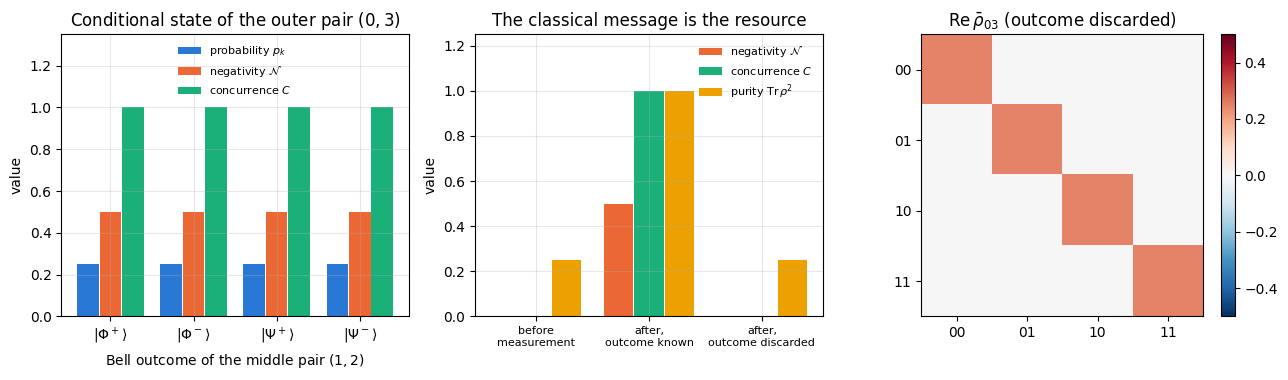

In [8]:
# ==============================================================================
# FIGURE: what the Bell measurement does to the outer pair (0,3)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9))

# (left) the four conditional outcomes: probability, negativity, concurrence
xpos = np.arange(4)
axes[0].bar(xpos - 0.27, [r[1] for r in rows], width=0.26, color=PALETTE[0], label="probability $p_k$")
axes[0].bar(xpos, [r[4] for r in rows], width=0.26, color=PALETTE[1], label=r"negativity $\mathcal{N}$")
axes[0].bar(xpos + 0.27, [r[5] for r in rows], width=0.26, color=PALETTE[2], label="concurrence $C$")
axes[0].set_xticks(xpos); axes[0].set_xticklabels(BELL_TEX)
axes[0].set_xlabel("Bell outcome of the middle pair $(1,2)$"); axes[0].set_ylabel("value")
axes[0].set_title("Conditional state of the outer pair $(0,3)$"); axes[0].legend(fontsize=8, loc="upper center")
axes[0].set_ylim(0, 1.35)

# (middle) before / conditional / averaged
labels = ["before\nmeasurement", "after,\noutcome known", "after,\noutcome discarded"]
negs = [neg2(rho_out_before), rows[0][4], neg2(rho_avg)]
cons = [concurrence(rho_out_before), rows[0][5], concurrence(rho_avg)]
purs = [float(purity(rho_out_before)), rows[0][6], float(purity(rho_avg))]   # all three measured, none assumed
xp = np.arange(3)
axes[1].bar(xp - 0.27, negs, width=0.26, color=PALETTE[1], label=r"negativity $\mathcal{N}$")
axes[1].bar(xp, cons, width=0.26, color=PALETTE[2], label="concurrence $C$")
axes[1].bar(xp + 0.27, purs, width=0.26, color=PALETTE[3], label=r"purity $\mathrm{Tr}\,\rho^2$")
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel("value"); axes[1].set_title("The classical message is the resource")
axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1.25)

# (right) the density matrices, real parts
im0 = axes[2].imshow(np.real(np.asarray(rho_avg)), vmin=-0.5, vmax=0.5, cmap="RdBu_r")
axes[2].set_xticks(range(4)); axes[2].set_yticks(range(4))
axes[2].set_xticklabels(["00", "01", "10", "11"]); axes[2].set_yticklabels(["00", "01", "10", "11"])
axes[2].set_title(r"$\mathrm{Re}\,\bar\rho_{03}$ (outcome discarded)"); axes[2].grid(False)
fig.colorbar(im0, ax=axes[2], fraction=0.046)
fig.tight_layout(); plt.show()

The left panel shows the flat $p_k=1/4$ distribution over outcomes together with the maximal entanglement of every conditional
state. The middle panel summarises the section: negativity and concurrence jump from $0$ to their maxima only when the
outcome is known, while the purity of the *unconditional* state stays at $1/4$. The right panel shows that
$\bar\rho_{03}$ really is the flat diagonal matrix $\mathbb 1_4/4$ — no off-diagonal coherence anywhere.

## 9. The protocol as hardware runs it: mid-circuit measurement, feed-forward, `vmap` over shots

So far we projected onto all four outcomes deliberately. A real device does something different: it measures **once**, gets a
random pair of bits, and a classical controller decides *within the coherence time* which gate to apply next. That is a
**mid-circuit measurement with feed-forward**, and it is the part of a quantum program that is hardest to express in a
differentiable, compilable array language — because the "if" depends on data that only exists at run time.

The JAX answer is to never branch. A measurement is

$$o=\big[\,u\ge p(0)\,\big],\qquad u\sim\mathrm{Uniform}[0,1),\qquad
  \vert\psi\rangle\to\frac{P_o\vert\psi\rangle}{\lVert P_o\vert\psi\rangle\rVert},$$

where the projector is *selected* by `jnp.where(o == 0, P0, P1)` rather than chosen by a Python `if`. Both branches are traced,
and XLA evaluates the selection on $2\times2$ matrices, at negligible cost. The correction is selected the same way, inside
`pauli_correction`. The result is a pure function `(key) -> (o1, o2, fidelity)` that can be `jit`-compiled once and `vmap`-ed over
an array of keys: thousands of independent runs of the experiment, in one fused XLA program, no Python loop.

> **JAX practice.** `jax.random.split(key, 2)` produces two statistically independent keys from one. Splitting *explicitly* (never
> reusing a key) is what makes stochastic JAX code reproducible: the same seed gives the same 4000 shots on any machine with the
> same JAX version, and
> `vmap` over `jax.random.split(key, n_shots)` is the idiomatic "run the experiment $n$ times".

One subtlety deserves attention: the two relay qubits must be measured **in sequence**, each conditioned on the collapse caused by
the previous one. Measuring qubit $1$ changes the probabilities for qubit $2$ (here it does not, because the four outcomes are
equiprobable and independent — but in general it does), so the code threads the collapsed, **renormalised** state from one
measurement into the next.

A frequency test against $p_k=1/4$ is a weak test of this code. All four outcomes are equally likely, so it cannot tell whether the
read-out codes were mapped onto the right Bell labels, and it cannot detect a wrong correction at all. The checkpoint below
therefore adds three tests that a faulty implementation fails:

* **unequal outcome probabilities.** Replace both links by the less-than-maximally entangled pair
  $\sqrt{a}\,\vert00\rangle+\sqrt{1-a}\,\vert11\rangle$ with $a=0.8$. The relay qubits are then in
  $\mathrm{diag}(a,1-a)\otimes\mathrm{diag}(a,1-a)$, and projecting onto the Bell basis gives
  $p(\Phi^\pm)=\tfrac12\big(a^2+(1-a)^2\big)=0.34$ and $p(\Psi^\pm)=a(1-a)=0.16$, so a permuted label map is detected;
* **a forgotten renormalisation.** If the state is not divided by its norm after the first collapse, the second Born probability
  is computed from a state of norm $1/2$: $p(o_2=0)=1/4$ instead of $1/2$, and the outcome frequencies become
  $(1/8,1/8,3/8,3/8)$;
* **swapped correction bits.** Applying $X^{o_1}Z^{o_2}$ instead of $X^{o_2}Z^{o_1}$ gives the right correction for $(0,0)$ and
  $(1,1)$ and the orthogonal Bell state for $(1,0)$ and $(0,1)$, so the mean fidelity drops to $1/2$.

In [9]:
# ==============================================================================
# STEP 5: one shot of entanglement swapping -- jit-able, vmap-able, with feed-forward
# ==============================================================================
def measure_z(key, psi, q):
    """Single projective Z-measurement of qubit q: Born rule + collapse, no Python branching.

    MATH   p(0) = <psi| P_0^{(q)} |psi> = rho_q[0,0];  outcome o = 1 with probability 1-p(0);
           |psi> -> P_o|psi> / sqrt(p(o)).
    JAX    `jnp.where(o == 0, P0, P1)` picks the projector from a TRACED outcome -> jit/vmap safe.
    """
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    o = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    psi = apply_gate(psi, jnp.where(o == 0, P0, P1), [q])
    return o, psi / jnp.linalg.norm(psi)


def swap_shot_from(key, psi0, measure=measure_z, correction=pauli_correction):
    """One run of entanglement swapping starting from the four-qubit state psi0.
    Returns (o1, o2, fidelity of (0,3) with |Phi+> after correction).

    STEPS  rotate the Bell basis of (1,2) -> measure qubit 1 -> measure qubit 2
           -> feed-forward correction X^{o2} Z^{o1} on Bob's qubit 3 -> fidelity of the outer pair.
    `measure` and `correction` are arguments only so that the checkpoint can insert deliberately wrong versions.
    """
    k1, k2 = jax.random.split(key)
    psi = bell_basis_change(psi0, QM1, QM2)
    o1, psi = measure(k1, psi, QM1)
    o2, psi = measure(k2, psi, QM2)
    psi = apply_gate(psi, correction(o1, o2), [QB])                # Bob's feed-forward
    rho_out = rdm(psi, [QA, QB])
    F = jnp.real(jnp.vdot(phi_plus_vec, rho_out @ phi_plus_vec))
    return o1, o2, F


@jax.jit
def swap_one_shot(key):
    """One complete run of entanglement swapping on |Phi+>_{01} |Phi+>_{23}.
    JAX    the whole thing is one traced function of a PRNG key: jit compiles it once, vmap runs many shots."""
    return swap_shot_from(key, two_bell_pairs())


N_SHOTS = 4000
t0 = time.perf_counter()
o1s, o2s, Fs = jax.vmap(swap_one_shot)(jax.random.split(jax.random.PRNGKey(2025), N_SHOTS))
o1s, o2s, Fs = np.asarray(jax.block_until_ready(o1s)), np.asarray(o2s), np.asarray(Fs)
t_run = time.perf_counter() - t0

codes = 2 * o1s + o2s                                              # 0..3 in the order (0,0),(0,1),(1,0),(1,1)
order = [0, 2, 1, 3]                                               # map to BELL_BITS order (o1,o2)
freq = np.array([np.mean(codes == c) for c in order])
err = binom_err(freq, N_SHOTS)
print(f"{N_SHOTS} shots (compile + run: {t_run:.2f} s)\n")
print(f"{'outcome':>9s} {'frequency':>12s} {'+- 1 sigma':>10s}  {'expected':>9s}  {'pulls':>6s}")
for lab, f, e in zip(BELL_LABELS, freq, err):
    print(f"{lab:>9s} {f:12.4f} {e:10.4f}  {0.25:9.4f}  {(f - 0.25) / e:6.2f}")
print(f"\nfidelity with |Phi+> after the feed-forward correction: "
      f"min = {Fs.min():.12f}   mean = {Fs.mean():.12f}   max = {Fs.max():.12f}")
assert Fs.min() > 1 - 1e3 * TOL and np.all(np.abs(freq - 0.25) < 5 * err)


# --- CHECKPOINT with teeth: unequal probabilities, and two deliberately wrong implementations ---------
def bell_freqs(o1s_, o2s_, order_):
    """Outcome frequencies in BELL_LABELS order, from read-out bits and a code -> label map."""
    c = 2 * np.asarray(o1s_) + np.asarray(o2s_)
    return np.array([np.mean(c == k) for k in order_])


def run_shots(shot_fn, seed):
    """vmap a one-shot function over N_SHOTS keys."""
    return [np.asarray(x) for x in jax.vmap(shot_fn)(jax.random.split(jax.random.PRNGKey(seed), N_SHOTS))]


def max_pull(f_hat, p_true):
    """Largest |f_hat - p| / sigma, with the binomial sigma of the HYPOTHESIS p."""
    return float(np.max(np.abs(f_hat - p_true) / np.sqrt(p_true * (1 - p_true) / N_SHOTS)))


A_WEAK = 0.8                                                       # sqrt(a)|00> + sqrt(1-a)|11> on both links
link = jnp.array([[np.sqrt(A_WEAK), 0.0], [0.0, np.sqrt(1 - A_WEAK)]], dtype=CDTYPE)
weak_pairs = jnp.einsum("ab,cd->abcd", link, link)
p_weak = np.array([0.5 * (A_WEAK**2 + (1 - A_WEAK)**2)] * 2 + [A_WEAK * (1 - A_WEAK)] * 2)   # Phi+, Phi-, Psi+, Psi-
o1w, o2w, _ = run_shots(jax.jit(lambda k: swap_shot_from(k, weak_pairs)), 2026)
z_right, z_permuted = max_pull(bell_freqs(o1w, o2w, order), p_weak), max_pull(bell_freqs(o1w, o2w, [0, 1, 2, 3]), p_weak)
print(f"\nweak links (a = {A_WEAK}): predicted p = {np.round(p_weak, 4)}, measured {np.round(bell_freqs(o1w, o2w, order), 4)}")
print(f"  largest pull with the label map used above: {z_right:5.2f} sigma;  with codes read as (o2,o1): {z_permuted:5.2f} sigma")


def measure_z_unnormalised(key, psi, q):
    """WRONG on purpose: Born rule + projection, but the collapsed state is not renormalised."""
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    o = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    return o, apply_gate(psi, jnp.where(o == 0, P0, P1), [q])


o1u, o2u, _ = run_shots(jax.jit(lambda k: swap_shot_from(k, two_bell_pairs(), measure=measure_z_unnormalised)), 2025)
z_unnorm = max_pull(bell_freqs(o1u, o2u, order), np.full(4, 0.25))
print(f"forgotten renormalisation: frequencies {np.round(bell_freqs(o1u, o2u, order), 4)}, "
      f"largest pull from 1/4 = {z_unnorm:.1f} sigma")
_, _, Fsw = run_shots(jax.jit(lambda k: swap_shot_from(k, two_bell_pairs(),
                                                        correction=lambda a, b: pauli_correction(b, a))), 2025)
print(f"swapped correction bits X^o1 Z^o2: mean fidelity {Fsw.mean():.4f}, min {Fsw.min():.4f}")
assert z_right < 5 and z_permuted > 5 and z_unnorm > 5 and Fsw.min() < 0.5

4000 shots (compile + run: 0.42 s)

  outcome    frequency +- 1 sigma   expected   pulls
     Phi+       0.2482     0.0068     0.2500   -0.26
     Phi-       0.2517     0.0069     0.2500    0.26
     Psi+       0.2402     0.0068     0.2500   -1.44
     Psi-       0.2597     0.0069     0.2500    1.41

fidelity with |Phi+> after the feed-forward correction: min = 1.000000000000   mean = 1.000000000000   max = 1.000000000000



weak links (a = 0.8): predicted p = [0.34 0.34 0.16 0.16], measured [0.3305 0.355  0.1618 0.1528]
  largest pull with the label map used above:  2.00 sigma;  with codes read as (o2,o1): 33.64 sigma


forgotten renormalisation: frequencies [0.1265 0.1268 0.362  0.3848], largest pull from 1/4 = 19.7 sigma


swapped correction bits X^o1 Z^o2: mean fidelity 0.5080, min 0.0000


The four outcomes come out flat at $1/4$ within the binomial error bars (the "pulls" column is the deviation in units of the
standard error and should be $O(1)$), and — this is the point of the feed-forward — **every single shot** ends with the outer pair
in $\vert\Phi^+\rangle$ with fidelity $1$ to machine precision, shot by shot. This is what Bob needs: he holds one pair, and a
protocol that reached fidelity $1$ only on average over shots would be of no use to him.

The second block shows that these tests can fail. With the weak links the outcome probabilities are $0.34$ and $0.16$, and the
frequencies match them only with the label map `order` used above; reading the codes with the two bits interchanged misses by many
standard deviations. A forgotten renormalisation after the first collapse moves the frequencies to $(1/8,1/8,3/8,3/8)$, far outside
the error bars, and interchanging the two correction bits leaves half of the shots in a Bell state orthogonal to
$\vert\Phi^+\rangle$ (fidelity $0$), so the mean fidelity falls to about $1/2$.

`vmap` bought thousands of independent mid-circuit-measurement experiments, each with its own random numbers, in a
single compiled call, with no Python loop anywhere. This is the pattern for every shot-based experiment in this course.

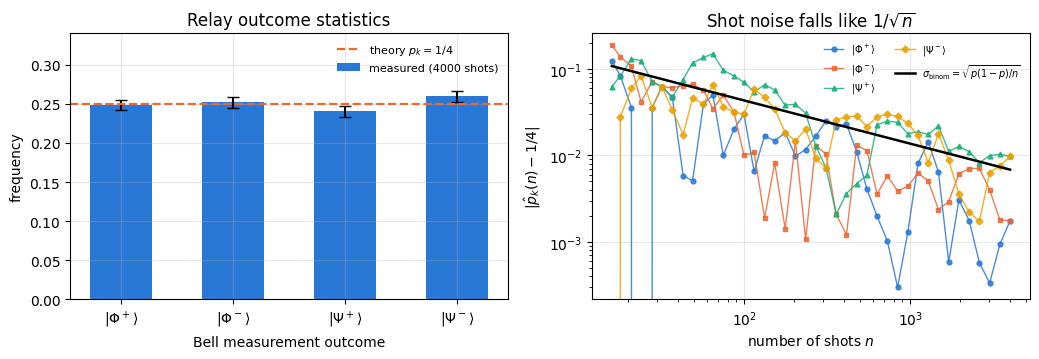

In [10]:
# ==============================================================================
# FIGURE: measured outcome statistics and per-shot fidelity
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
axes[0].bar(np.arange(4), freq, yerr=err, width=0.55, color=PALETTE[0], capsize=4,
            label=f"measured ({N_SHOTS} shots)")
axes[0].axhline(0.25, color=PALETTE[1], ls="--", lw=1.6, label=r"theory $p_k=1/4$")
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(BELL_TEX)
axes[0].set_xlabel("Bell measurement outcome"); axes[0].set_ylabel("frequency")
axes[0].set_title("Relay outcome statistics"); axes[0].legend(fontsize=8); axes[0].set_ylim(0, 0.34)

n_axis = np.unique(np.round(np.logspace(1.2, np.log10(N_SHOTS), 40)).astype(int))
for k, c in enumerate(order):
    run = np.cumsum(codes == c)[n_axis - 1] / n_axis                # running frequency estimate
    axes[1].loglog(n_axis, np.abs(run - 0.25), MARKERS[k] + "-", color=PALETTE[k], ms=3.5, lw=1,
                   alpha=0.85, label=BELL_TEX[k])
axes[1].loglog(n_axis, np.sqrt(0.25 * 0.75 / n_axis), "k-", lw=1.8,
               label=r"$\sigma_{\mathrm{binom}}=\sqrt{p(1-p)/n}$")
axes[1].set_xlabel("number of shots $n$"); axes[1].set_ylabel(r"$\vert \hat p_k(n)-1/4\vert$")
axes[1].set_title("Shot noise falls like $1/\\sqrt{n}$"); axes[1].legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

The left panel is the statistical check at the full shot budget; the right panel shows the *running* estimate of each outcome
probability as shots accumulate. The deviations wander inside the $1/\sqrt n$ envelope of the binomial standard deviation
$\sigma=\sqrt{p(1-p)/n}$, drawn as the solid reference line — the signature of an unbiased estimator with independent samples.
Nothing here is specific to entanglement swapping: it is how *every* measured quantity in this course converges.

## 10. Noisy links: Werner states and the product rule $W_{\text{out}}=W_1W_2$

Real links are not Bell pairs. A fibre, a memory or an imperfect source produces a mixed state, and the standard one-parameter
model is the **Werner (isotropic) state**

$$\rho_W=W\,\vert\Phi^+\rangle\langle\Phi^+\vert+(1-W)\,\frac{\mathbb 1_4}{4},\qquad 0\le W\le1, \tag{7}$$

i.e. "a Bell pair with probability $W$, white noise otherwise". Its fidelity with $\vert\Phi^+\rangle$ is
$F=W+\tfrac{1-W}{4}=\tfrac{1+3W}{4}$.

### 10.1 Werner states are random Pauli errors

The key to everything below is to rewrite Eq. (7) as an *error model*. By Eq. (3) the four states
$(\sigma_k\otimes\mathbb 1)\vert\Phi^+\rangle$, $\sigma_k\in\{\mathbb 1,X,Y,Z\}$, are precisely the four Bell states, so by Eq. (2)

$$\frac{\mathbb 1_4}{4}=\frac14\sum_k\vert B_k\rangle\langle B_k\vert
 =\frac14\sum_k(\sigma_k\otimes\mathbb 1)\vert\Phi^+\rangle\langle\Phi^+\vert(\sigma_k\otimes\mathbb 1).$$

Substituting into Eq. (7):

$$\rho_W=\sum_k q_k\,(\sigma_k\otimes\mathbb 1)\,\vert\Phi^+\rangle\langle\Phi^+\vert\,(\sigma_k\otimes\mathbb 1),\qquad
  q_{\mathbb 1}=\frac{1+3W}{4},\quad q_X=q_Y=q_Z=\frac{1-W}{4}. \tag{8}$$

In words: **a Werner state is a perfect Bell pair to which a random Pauli error $\sigma_k$ has been applied**, drawn from the
distribution $q$. Written compactly with the uniform distribution $u_k=1/4$ and the point mass $\delta_k$ at $k=\mathbb 1$,

$$q=(1-W)\,u+W\,\delta . \tag{9}$$

### 10.2 What the swap does to the errors

Take link $(0,1)$ carrying the error $\sigma_a$ on its inner qubit $1$, and link $(2,3)$ carrying $\sigma_b$ on its inner qubit
$2$ — the inner halves are the ones that travelled to the relay, so that is where noise naturally sits, and by Eq. (4) it makes no
difference anyway. Push both errors **out**, away from the relay, with Eq. (4): an error on qubit $1$ becomes
$\sigma_a^{\mathsf T}$ on qubit $0$, and an error on qubit $2$ becomes $\sigma_b^{\mathsf T}$ on qubit $3$. Transposition moves no
error onto a different label (Section 3.2), so the two distributions $q^{(1)},q^{(2)}$ survive the move unchanged.
The state is therefore

$$\big(\sigma_a^{\mathsf T}\big)^{(0)}\big(\sigma_b^{\mathsf T}\big)^{(3)}\;\vert\Phi^+\rangle_{01}\vert\Phi^+\rangle_{23},$$

with the errors sitting on qubits the relay never touches. Hence the Bell measurement proceeds exactly as in Eq. (5) — outcome $k$
with probability $1/4$, outer pair in $\vert B_k\rangle$ — and Bob's correction restores $\vert\Phi^+\rangle$ *before* the errors
are taken into account. What is left is

$$\big(\sigma_a^{\mathsf T}\big)^{(0)}\big(\sigma_b^{\mathsf T}\big)^{(3)}\vert\Phi^+\rangle_{03}
 \;\propto\;\big(\sigma_a^{\mathsf T}\sigma_b\big)^{(0)}\vert\Phi^+\rangle_{03},$$

using Eq. (4) once more to move the error from qubit $3$ to qubit $0$. Signs and factors of $i$ are global phases and drop out of
the density matrix. **The residual error is the product of the two link errors.**

### 10.3 The product rule

So the output error distribution is the **convolution** of the two input distributions over the group
$\{\mathbb 1,X,Y,Z\}$ (which is the Klein four-group $\mathbb Z_2\times\mathbb Z_2$ once phases are dropped). Nothing in the
argument used isotropy: it holds for any two **Bell-diagonal** links, i.e. for any pair of random-Pauli-error distributions, and
the output is then Bell-diagonal with the convolved distribution, whatever the relay's outcome was. The Werner family is special
only in that the convolution closes on a single parameter. Convolution is easy
in the form (9), because the uniform distribution absorbs everything: $u*u=u$, $u*\delta=\delta*u=u$, $\delta*\delta=\delta$.
With $q^{(1)}=(1-W_1)u+W_1\delta$ and $q^{(2)}=(1-W_2)u+W_2\delta$,

$$\begin{aligned}
q^{(1)}*q^{(2)}&=(1-W_1)(1-W_2)\,u*u+(1-W_1)W_2\,u*\delta+W_1(1-W_2)\,\delta*u+W_1W_2\,\delta*\delta \\
&=\big[(1-W_1)(1-W_2)+(1-W_1)W_2+W_1(1-W_2)\big]u+W_1W_2\,\delta \\
&=(1-W_1W_2)\,u+W_1W_2\,\delta .
\end{aligned}$$

Comparing with Eq. (9): the output is again a Werner state, with

$$\boxed{\,W_{\text{out}}=W_1\,W_2\,} \tag{10}$$

— the Werner parameters **multiply**. In terms of the fidelities $F_i=\tfrac{1+3W_i}{4}$, i.e. $W_i=\tfrac{4F_i-1}{3}$,

$$F_{\text{out}}=\frac{1+3W_1W_2}{4}=\frac{1+4F_1F_2-F_1-F_2}{3}=F_1F_2+\frac{(1-F_1)(1-F_2)}{3} . \tag{10a}$$

The second form can be read off the error picture directly: the output is error-free if both links are error-free (probability
$F_1F_2$) or if both carry the *same* error, which cancels in the product $\sigma_a^{\mathsf T}\sigma_b$ (probability
$\tfrac{1-F_1}{3}\cdot\tfrac{1-F_2}{3}$ for each of the three errors). The fidelity composes by this bilinear law, which is less
convenient than a product; that is why $W$ is the natural variable of a repeater analysis.

### 10.4 When the output is still entangled

The partial transpose of $\rho_W$ has eigenvalues $\tfrac{1+W}{4}$ (three times) and $\tfrac{1-3W}{4}$, so

$$\mathcal N(\rho_W)=\max\Big(0,\ \frac{3W-1}{4}\Big),\qquad C(\rho_W)=\max\Big(0,\ \frac{3W-1}{2}\Big),$$

and the state is **entangled if and only if $W>1/3$**: the partial transpose of this family turns negative exactly there
(Peres, 1996), and for two qubits a positive partial transpose implies separability (Horodecki, 1996). We check all of this
numerically now, on the density tensor.

In [11]:
# ==============================================================================
# STEP 6: swapping with Werner links -- on the four-qubit density tensor
# ==============================================================================
BELL_KEYS = ["phi+", "phi-", "psi+", "psi-"]          # engine names, in BELL_LABELS / BELL_BITS order


def werner_matrix(W):
    """Werner / isotropic two-qubit state of Eq. (7) as a 4x4 matrix."""
    v = bell_state("phi+").reshape(-1)
    return W * jnp.outer(v, jnp.conj(v)) + (1 - W) * jnp.eye(4, dtype=CDTYPE) / 4


def bell_diag_matrix(lams):
    """Bell-diagonal two-qubit state  rho = sum_k lambda_k |B_k><B_k|  as a 4x4 matrix.

    MATH   by Eq. (3) this is |Phi+> with a random Pauli error of distribution `lams` (BELL_BITS order).
           The Werner state of Eq. (8) is the ISOTROPIC case lambda_2 = lambda_3 = lambda_4.
    """
    out = jnp.zeros((4, 4), dtype=CDTYPE)
    for lam, key in zip(lams, BELL_KEYS):
        v = bell_state(key).reshape(-1)
        out = out + lam * jnp.outer(v, jnp.conj(v))
    return out


def bell_weights(rho_mat):
    """The four Bell-basis populations <B_k|rho|B_k> of a 4x4 density matrix, in BELL_BITS order."""
    rho_mat = jnp.asarray(rho_mat, dtype=CDTYPE)
    return np.array([float(jnp.real(jnp.vdot(bell_state(k).reshape(-1), rho_mat @ bell_state(k).reshape(-1))))
                     for k in BELL_KEYS])


def bit_convolve(q1, q2):
    """Convolution of two error distributions over the group Z2 x Z2, both in BELL_BITS order.
    MATH   (q1 * q2)[c] = sum_{a + b = c} q1[a] q2[b] , with '+' the bitwise XOR of the label pairs."""
    out = np.zeros(4)
    for i, (a1, a2) in enumerate(BELL_BITS):
        for j, (b1, b2) in enumerate(BELL_BITS):
            out[BELL_BITS.index((a1 ^ b1, a2 ^ b2))] += q1[i] * q2[j]
    return out


def two_links_dm(link1, link2):
    """Density TENSOR (rank 8) of two independent links on qubits (0,1) and (2,3).
    Each argument is either a Werner parameter (a scalar) or a 4x4 two-qubit density matrix.

    IMPLEMENTATION  each link is a (2,2,2,2) tensor with axes (ket,ket,bra,bra); the tensor product of the
    two must be re-ordered so that ALL ket axes come first:  einsum("abAB,cdCD->abcdABCD", link01, link23).
    """
    m1 = werner_matrix(link1) if np.ndim(link1) == 0 else jnp.asarray(link1, dtype=CDTYPE)
    m2 = werner_matrix(link2) if np.ndim(link2) == 0 else jnp.asarray(link2, dtype=CDTYPE)
    return jnp.einsum("abAB,cdCD->abcdABCD", dm_tensor(m1, 2), dm_tensor(m2, 2))


def swap_dm(rho4, o1, o2):
    """Bell measurement on qubits (1,2) of a four-qubit density tensor, conditioned on the result (o1,o2),
    followed by Bob's correction. Returns (probability, 4x4 reduced density matrix of the outer pair).

    MATH   rho -> (P_{o1} P_{o2}) U_BM rho U_BM^dag (P_{o1} P_{o2}) / p ,  p = Tr[...]
           then U(o1,o2) on qubit 3, then partial trace over (1,2).
    """
    r = apply_gate_dm(rho4, CNOT, [QM1, QM2])                    # Bell basis -> computational basis
    r = apply_gate_dm(r, H, [QM1])
    r = apply_gate_dm(r, jnp.where(o1 == 0, P0, P1), [QM1])      # projectors: P rho P
    r = apply_gate_dm(r, jnp.where(o2 == 0, P0, P1), [QM2])
    p = jnp.real(jnp.trace(dm_matrix(r)))
    r = r / jnp.clip(p, 1e-300, None)
    r = apply_gate_dm(r, pauli_correction(o1, o2), [QB])         # Bob's correction
    return p, rdm_dm(r, [QA, QB])


def werner_parameter(rho_mat):
    """Extract W from a state of the form (7):  W = (4 F - 1)/3  with F = <Phi+|rho|Phi+>."""
    v = bell_state("phi+").reshape(-1)
    F = jnp.real(jnp.vdot(v, jnp.asarray(rho_mat, dtype=CDTYPE) @ v))
    return float((4 * F - 1) / 3)


# --- CHECKPOINT: the product rule, Eq. (10), for a grid of input parameters --------------------------
# The last column is the one with teeth.  W_out, the negativity and the concurrence of a Bell-diagonal
# state all depend ONLY on its largest Bell population, so none of them can detect a violation of
# ISOTROPY: a state with weights (0.8575, 0.0998, 0.0285, 0.0143) returns exactly the same three numbers
# as the Werner state with W = 0.81 while differing from it by 0.026 entry by entry.  We therefore also
# compare the output with werner_matrix(W1 W2) element by element.
print(f"{'W1':>6s} {'W2':>6s} {'outcome':>8s} {'p':>8s} {'W_out':>9s} {'W1*W2':>9s} {'err':>9s} "
      f"{'N(out)':>8s} {'(3W-1)/4':>9s} {'C(out)':>8s} {'|rho-Werner|':>13s}")
err_prod, err_neg, err_iso = 0.0, 0.0, 0.0
err_F = 0.0
for W1, W2 in [(1.0, 1.0), (0.9, 0.9), (0.8, 0.6), (0.5, 0.5), (0.4, 0.9), (0.3, 1.0)]:
    rho4w = two_links_dm(W1, W2)
    for (o1, o2) in (BELL_BITS if W1 == W2 == 0.9 else [(0, 0)]):
        p, rho_out = swap_dm(rho4w, o1, o2)
        Wo, Nn, Cc = werner_parameter(rho_out), neg2(rho_out), concurrence(rho_out)
        Npred = max(0.0, (3 * W1 * W2 - 1) / 4)
        d_iso = max_abs(rho_out - werner_matrix(W1 * W2))
        err_prod = max(err_prod, abs(Wo - W1 * W2))
        err_neg = max(err_neg, abs(Nn - Npred))
        err_iso = max(err_iso, d_iso)
        F1, F2, F_out = (1 + 3 * W1) / 4, (1 + 3 * W2) / 4, float(jnp.real(rho_out[0, 0] + rho_out[0, 3]
                                                                         + rho_out[3, 0] + rho_out[3, 3])) / 2
        err_F = max(err_F, abs(F_out - (F1 * F2 + (1 - F1) * (1 - F2) / 3)))   # Eq. (10a)
        print(f"{W1:6.2f} {W2:6.2f} {str((o1, o2)):>8s} {float(p):8.4f} {Wo:9.6f} {W1 * W2:9.6f} "
              f"{abs(Wo - W1 * W2):9.1e} {Nn:8.5f} {Npred:9.5f} {Cc:8.5f} {d_iso:13.1e}")
print(f"\nmax |W_out - W1 W2| = {err_prod:.2e}     max |N - max(0,(3W-1)/4)| = {err_neg:.2e}"
      f"     max |rho_out - rho_Werner(W1 W2)| = {err_iso:.2e}")
print(f"max |F_out - [F1 F2 + (1-F1)(1-F2)/3]| = {err_F:.2e}   (Eq. (10a))")
assert err_prod < 1e3 * TOL and err_neg < 1e3 * TOL and err_iso < 1e3 * TOL and err_F < 1e3 * TOL
# the isotropy column really is an independent test: a skewed link with the same fidelity fools the others
lam_skew = [(1 + 3 * 0.81) / 4, 0.1425 * 0.7, 0.1425 * 0.2, 0.1425 * 0.1]
rho_skew = bell_diag_matrix(lam_skew)
print(f"\nskewed Bell-diagonal state with the same fidelity as Werner(W=0.81):  "
      f"W = {werner_parameter(rho_skew):.6f}, N = {neg2(rho_skew):.6f}, C = {concurrence(rho_skew):.6f}  "
      f"-> identical;   |rho - Werner| = {max_abs(rho_skew - werner_matrix(0.81)):.3f}  -> not identical")
assert abs(werner_parameter(rho_skew) - 0.81) < 1e3 * TOL and max_abs(rho_skew - werner_matrix(0.81)) > 0.01

# --- CHECKPOINT: the convolution rule for links that are NOT isotropic -------------------------------
# Section 10.2 derives the group convolution for ARBITRARY Bell-diagonal links; only Section 10.3
# specialises it to the Werner family.  Here we test the general statement.
q_a = np.array([0.55, 0.25, 0.15, 0.05])
q_b = np.array([0.70, 0.05, 0.05, 0.20])
p_g, rho_g = swap_dm(two_links_dm(bell_diag_matrix(q_a), bell_diag_matrix(q_b)), 0, 0)
q_pred, q_meas = bit_convolve(q_a, q_b), bell_weights(rho_g)
print(f"\ngeneral Bell-diagonal links   q_a = {q_a}   q_b = {q_b}   p(outcome) = {float(p_g):.6f}")
print(f"  predicted q_a * q_b = {np.round(q_pred, 6)}")
print(f"  measured  populations = {np.round(q_meas, 6)}   max err = {np.max(np.abs(q_pred - q_meas)):.2e}")
print(f"  output is Bell-diagonal but NOT Werner: |rho_out - Werner({werner_parameter(rho_g):.4f})| = "
      f"{max_abs(rho_g - werner_matrix(werner_parameter(rho_g))):.4f}")
assert np.max(np.abs(q_pred - q_meas)) < 1e3 * TOL and abs(float(p_g) - 0.25) < 1e3 * TOL
assert max_abs(rho_g - bell_diag_matrix(q_pred)) < 1e3 * TOL          # Bell-diagonal, no coherences
assert max_abs(rho_g - werner_matrix(werner_parameter(rho_g))) > 0.01  # but not isotropic

    W1     W2  outcome        p     W_out     W1*W2       err   N(out)  (3W-1)/4   C(out)  |rho-Werner|


  1.00   1.00   (0, 0)   0.2500  1.000000  1.000000   3.3e-16  0.50000   0.50000  1.00000       1.1e-16
  0.90   0.90   (0, 0)   0.2500  0.810000  0.810000   1.1e-16  0.35750   0.35750  0.71500       1.7e-16
  0.90   0.90   (1, 0)   0.2500  0.810000  0.810000   1.1e-16  0.35750   0.35750  0.71500       1.7e-16
  0.90   0.90   (0, 1)   0.2500  0.810000  0.810000   1.1e-16  0.35750   0.35750  0.71500       1.7e-16
  0.90   0.90   (1, 1)   0.2500  0.810000  0.810000   1.1e-16  0.35750   0.35750  0.71500       1.7e-16
  0.80   0.60   (0, 0)   0.2500  0.480000  0.480000   1.7e-16  0.11000   0.11000  0.22000       5.6e-17
  0.50   0.50   (0, 0)   0.2500  0.250000  0.250000   8.3e-17  0.00000   0.00000  0.00000       5.6e-17
  0.40   0.90   (0, 0)   0.2500  0.360000  0.360000   1.7e-16  0.02000   0.02000  0.04000       5.6e-17
  0.30   1.00   (0, 0)   0.2500  0.300000  0.300000   1.7e-16  0.00000   0.00000  0.00000       5.6e-17

max |W_out - W1 W2| = 3.33e-16     max |N - max(0,(3W-1)/4)| = 

The measured $W_{\text{out}}$ equals $W_1W_2$ to machine precision for every pair we tried (for $W_1=W_2=0.9$ for all four Bell
outcomes), the fidelity obeys Eq. (10a), and the whole output density matrix coincides with $\rho_{W_1W_2}$ entry by entry, so the
output is a Werner state and agrees with the prediction in more than its fidelity. The outcome probability stays at $1/4$ regardless of how noisy the links are: each half of a Bell-diagonal
pair is maximally mixed, so the relay's own statistics are flat and it learns *nothing* about the quality of the links from them.
The negativity follows $\max(0,(3W-1)/4)$ exactly, and the last row of the grid is the interesting one: two links with $W_1=0.3$ and
$W_2=1.0$ give $W_{\text{out}}=0.3<1/3$, so the swapped pair is **separable** — the protocol ran perfectly and produced no
entanglement at all, because there was not enough to start with.

The last block tests the *general* statement of Section 10.3 on two links that are Bell-diagonal but deliberately not isotropic.
The measured output populations reproduce the group convolution $q_a*q_b$ to $10^{-16}$, the output has no Bell-basis coherences,
and it is **not** a Werner state. This is why the isotropy column above is a meaningful test: a non-isotropic output is possible
and would be detected.

> **Numerical practice.** We verified an analytic claim (Eq. (10)) that was derived by a *group-theoretic* argument — error
> distributions convolving — using a completely different numerical route: projectors and partial traces on a rank-8 density
> tensor. When two such different derivations agree to $10^{-16}$, the chance that both are wrong in the same way is negligible.
> But notice how carefully the comparison had to be chosen: $W$, the negativity and the concurrence of a Bell-diagonal state are
> all functions of its largest population alone, so all three agree with the Werner prediction even for states that are not
> Werner at all. A checkpoint is useful only if it can fail for the error it is supposed to catch.

## 11. Repeater chains: why purification is not optional

A quantum repeater divides a long channel into $n$ elementary links, distributes entanglement on each link separately (this can be
done in parallel, and retried until it succeeds, which is the whole point), and then performs $n-1$ swaps to connect them into one
end-to-end pair. Applying Eq. (10) repeatedly, $n$ links with the same parameter $W$ give

$$W_{\text{chain}}(n)=W^{\,n},\qquad F_{\text{chain}}(n)=\frac{1+3W^{\,n}}{4}\;\xrightarrow[n\to\infty]{}\;\frac14 .$$

The end-to-end state decays **exponentially in the number of links** towards the useless maximally mixed state, and it stops being
entangled at all as soon as $W^n\le1/3$, i.e. after

$$n_{\max}=\frac{\ln(1/3)}{\ln W}$$

links. For $W=0.95$ that is about $21$ links; for $W=0.9$ about $10$. Every link and every Bell measurement was assumed to
succeed, so photon loss plays no role here: the decay is caused by error accumulation alone.

The remedy, proposed in 1998 by Briegel, Dür, Cirac and Zoller in the paper that introduced the quantum repeater, is
**entanglement purification**: take two noisy pairs of parameter $W$, perform local operations and classical communication, and
with some probability obtain *one* pair with a **higher** $W$. Interleaving purification with swapping keeps the working fidelity
above threshold at every nesting level. In the scheme of Briegel, Dür, Cirac and Zoller the channel is cut into $N$ segments and
purification alternates with swapping over $\log_L N$ nesting levels; the total number of elementary pairs consumed then scales as
$N^{\log_LM+1}$ — **polynomially** in the distance rather than exponentially — and in their refined version each repeater station
has to control only $O(\log N)$ qubits at a time, at the price of a polynomially longer total run time. Their analysis requires the
local gates and measurements to be better than a threshold (their worked example uses reliabilities of $0.995$), which is the part
of the claim the title of the paper refers to. Everything in this notebook is the "swapping" half of that machinery; the
"purification" half is a protocol of the same family (local Bell-type measurements plus classical communication), and Exercise 7
asks for one round of it.

Let us verify the chain formula by iterating the swap on density tensors. The chain carries the full $4\times4$ output state from
one swap to the next, so that the final comparison with $\rho_{W^n}$ also tests that the state stays isotropic along the chain.

In [12]:
# ==============================================================================
# STEP 7: a repeater chain -- iterate the swap and compare with W^n
# ==============================================================================
N_LINKS_MAX = 8
W_LIST = [1.0, 0.98, 0.95, 0.90, 0.80]

chain, chain_neg = {}, {}
for W in W_LIST:
    rho_chain = werner_matrix(W)                              # after 1 link: the link itself
    Ws, negs_ = [werner_parameter(rho_chain)], [neg2(rho_chain)]
    for n in range(2, N_LINKS_MAX + 1):
        p, rho_chain = swap_dm(two_links_dm(rho_chain, W), 0, 0)   # connect the chain so far (full state) with one more link
        Ws.append(werner_parameter(rho_chain))
        negs_.append(neg2(rho_chain))                         # negativity measured on the actual output state
    chain[W], chain_neg[W] = np.array(Ws), np.array(negs_)
    pred = W ** np.arange(1, N_LINKS_MAX + 1)
    d_state = max_abs(rho_chain - werner_matrix(W ** N_LINKS_MAX))
    print(f"W = {W:.2f}:  measured W_chain = " + " ".join(f"{x:7.4f}" for x in chain[W]))
    print(f"           W^n           = " + " ".join(f"{x:7.4f}" for x in pred) +
          f"   max err = {np.max(np.abs(chain[W] - pred)):.1e}   |rho_8 - Werner(W^8)| = {d_state:.1e}")
    assert np.max(np.abs(chain[W] - pred)) < 1e-9 and d_state < 1e-9

nmax = {W: (np.log(1 / 3) / np.log(W) if W < 1 else np.inf) for W in W_LIST}
print("\nlast link at which the end-to-end pair is still entangled (W^n > 1/3):")
for W in W_LIST:
    n_meas = int(np.sum(chain[W] > 1 / 3))
    print(f"  W = {W:.2f}:  n_max (formula) = {nmax[W]:6.2f}   last entangled n in our chain = {n_meas}"
          + ("  (chain not long enough to lose it)" if n_meas == N_LINKS_MAX else ""))

W = 1.00:  measured W_chain =  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000
           W^n           =  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   max err = 4.4e-16   |rho_8 - Werner(W^8)| = 1.1e-16
W = 0.98:  measured W_chain =  0.9800  0.9604  0.9412  0.9224  0.9039  0.8858  0.8681  0.8508
           W^n           =  0.9800  0.9604  0.9412  0.9224  0.9039  0.8858  0.8681  0.8508   max err = 7.8e-16   |rho_8 - Werner(W^8)| = 1.7e-16
W = 0.95:  measured W_chain =  0.9500  0.9025  0.8574  0.8145  0.7738  0.7351  0.6983  0.6634
           W^n           =  0.9500  0.9025  0.8574  0.8145  0.7738  0.7351  0.6983  0.6634   max err = 5.6e-16   |rho_8 - Werner(W^8)| = 1.1e-16
W = 0.90:  measured W_chain =  0.9000  0.8100  0.7290  0.6561  0.5905  0.5314  0.4783  0.4305
           W^n           =  0.9000  0.8100  0.7290  0.6561  0.5905  0.5314  0.4783  0.4305   max err = 4.4e-16   |rho_8 - Werner(W^8)| = 8.3e-17


W = 0.80:  measured W_chain =  0.8000  0.6400  0.5120  0.4096  0.3277  0.2621  0.2097  0.1678
           W^n           =  0.8000  0.6400  0.5120  0.4096  0.3277  0.2621  0.2097  0.1678   max err = 5.6e-16   |rho_8 - Werner(W^8)| = 5.6e-17

last link at which the end-to-end pair is still entangled (W^n > 1/3):
  W = 1.00:  n_max (formula) =    inf   last entangled n in our chain = 8  (chain not long enough to lose it)
  W = 0.98:  n_max (formula) =  54.38   last entangled n in our chain = 8  (chain not long enough to lose it)
  W = 0.95:  n_max (formula) =  21.42   last entangled n in our chain = 8  (chain not long enough to lose it)
  W = 0.90:  n_max (formula) =  10.43   last entangled n in our chain = 8  (chain not long enough to lose it)
  W = 0.80:  n_max (formula) =   4.92   last entangled n in our chain = 4


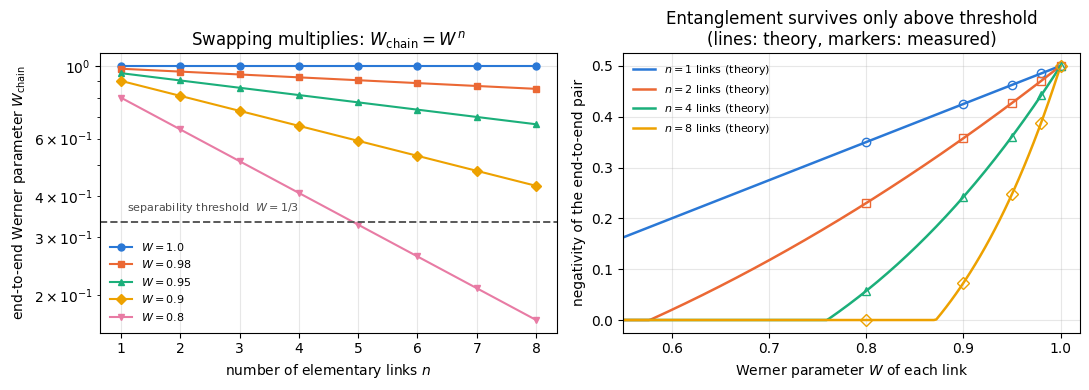

In [13]:
# ==============================================================================
# FIGURE: the repeater chain -- exponential decay and the entanglement threshold
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
ns = np.arange(1, N_LINKS_MAX + 1)
for k, W in enumerate(W_LIST):
    axes[0].semilogy(ns, chain[W], MARKERS[k] + "-", color=PALETTE[k], ms=5, label=f"$W={W}$")
axes[0].axhline(1 / 3, color="0.35", ls="--", lw=1.4)
axes[0].text(1.1, 0.36, r"separability threshold  $W=1/3$", fontsize=8, color="0.3")
axes[0].set_xlabel("number of elementary links $n$"); axes[0].set_ylabel(r"end-to-end Werner parameter $W_{\rm chain}$")
axes[0].set_title(r"Swapping multiplies: $W_{\rm chain}=W^{\,n}$"); axes[0].legend(fontsize=8)

Wgrid = np.linspace(0.0, 1.0, 400)
N_SHOW = [1, 2, 4, 8]
for k, n in enumerate(N_SHOW):
    axes[1].plot(Wgrid, np.maximum(0.0, (3 * Wgrid ** n - 1) / 4), "-", color=PALETTE[k], lw=1.8,
                 label=f"$n={n}$ links (theory)")
for k, n in enumerate(N_SHOW):                                    # measured points from the chains above
    axes[1].plot(W_LIST, [chain_neg[W][n - 1] for W in W_LIST], MARKERS[k], color=PALETTE[k], ms=6, mfc="none")
axes[1].set_xlabel("Werner parameter $W$ of each link"); axes[1].set_ylabel(r"negativity of the end-to-end pair")
axes[1].set_title("Entanglement survives only above threshold\n(lines: theory, markers: measured)")
axes[1].legend(fontsize=8); axes[1].set_xlim(0.55, 1.02)
fig.tight_layout(); plt.show()

Left: the measured end-to-end parameter (markers, from actual density-tensor swaps) lies exactly on the straight lines of the
semi-log plot, i.e. on $W^n$, and crosses the separability threshold $1/3$ after a number of links that shrinks quickly as the link
quality drops. In the chains we ran, $W=0.80$ is the only one that dies inside eight links (it is separable from $n=5$ on,
$0.8^5=0.328<1/3$); $W=0.90$ survives to $n=10$, as $n_{\max}=10.43$ predicts. Right: the end-to-end negativity as a function of
link quality for chains of different length. The threshold moves to $W=(1/3)^{1/n}$, which is $0.87$ for $n=8$: at eight links
$W=0.90$ still gives a (barely) entangled pair, negativity $0.073$ out of the maximal $0.5$, while $W=0.80$ gives exactly zero.
**Without purification, distance costs entanglement exponentially.**

## 12. Superdense coding: sending two bits down one qubit

We now run the same machinery backwards. Alice and Bob share one Bell pair $\vert\Phi^+\rangle_{AB}$, distributed at some earlier,
convenient time — perhaps by the repeater of the previous section. Later, Alice learns two classical bits $(m_1,m_2)$ that she must
send to Bob, and the only channel available is one that transmits **a single qubit**.

| step | who | action |
|---|---|---|
| 0 | — | Alice and Bob share $\vert\Phi^+\rangle_{AB}$ (Alice holds $A$, Bob holds $B$) |
| 1 | Alice | apply $U_{m_1m_2}=X^{m_2}Z^{m_1}$ to her qubit $A$ |
| 2 | Alice | send qubit $A$ to Bob |
| 3 | Bob | Bell measurement on $(A,B)$: $\mathrm{CNOT}(A\to B)$, $H$ on $A$, read both qubits |
| 4 | Bob | the two read-out bits **are** $(m_1,m_2)$ |

### 12.1 The algebra

By Eq. (3), step 1 turns the shared state into one of the four Bell states:

$$\begin{aligned}
(m_1,m_2)=(0,0)&:\quad \vert\Phi^+\rangle, &\qquad (m_1,m_2)=(1,0)&:\quad Z_A\vert\Phi^+\rangle=\vert\Phi^-\rangle, \\
(m_1,m_2)=(0,1)&:\quad X_A\vert\Phi^+\rangle=\vert\Psi^+\rangle, &\qquad (m_1,m_2)=(1,1)&:\quad X_AZ_A\vert\Phi^+\rangle=-\vert\Psi^-\rangle .
\end{aligned}$$

The four Bell states are **orthonormal**, hence perfectly distinguishable by a single projective measurement — and by Section 3.3
that measurement is a $\mathrm{CNOT}$, an $H$ and two single-qubit read-outs, with the bits coming out in exactly the encoding
convention. So Bob recovers $(m_1,m_2)$ with probability $1$. Two bits, one transmitted qubit.

### 12.2 Three consequences

1. **Alice never touches Bob's qubit**, yet her local operation changes the *global* state from one orthogonal state to another.
   That is only possible because the pair was entangled: a product state $\vert a\rangle\vert b\rangle$ cannot be moved between
   four mutually orthogonal states by a unitary acting on $\vert a\rangle$ alone (there are only two orthogonal directions available
   in a single qubit).
2. **Alice's qubit alone carries no information.** Her reduced state is $\mathbb 1/2$ before *and* after the encoding, for every
   message — we verify this below. An eavesdropper who intercepts the travelling qubit and does not hold $B$ learns nothing about
   the message from it (Section 13 makes this quantitative). She can, however, disturb or withhold the qubit, so this property
   alone does not make the protocol secure.
3. **The entanglement is consumed.** After step 4 the pair is in a computational basis state: no entanglement is left. One ebit
   was spent to carry one extra bit.

### 12.3 The resource ledger, and the duality with teleportation

Write the two protocols side by side, with "$\to$" meaning "can be simulated using":

| protocol | consumes | achieves |
|---|---|---|
| teleportation | $1$ ebit $+$ $2$ classical bits | $1$ transmitted qubit |
| superdense coding | $1$ ebit $+$ $1$ transmitted qubit | $2$ classical bits |

They are *duals*: each one's output appears in the other's input list, and composing them is consistent (teleporting a qubit
with one ebit and two bits, then using that qubit and a second ebit to send two bits, returns two bits for two ebits and two
bits, with no net gain). Both are built
from the identical hardware primitives: prepare a Bell pair, apply $X^{a}Z^{b}$ on one half, perform a Bell measurement. In
teleportation the Bell measurement comes *first* and the Pauli comes *second* (as a correction chosen by the message); in dense
coding the Pauli comes *first* (as the encoding chosen by the message) and the Bell measurement comes *second*. Entanglement
swapping, Section 4, is the third member of the family: a Bell measurement on halves of two pairs.

In [14]:
# ==============================================================================
# STEP 8: superdense coding -- encode, transmit, decode; exact probabilities for all four messages
# ==============================================================================
def dense_encode(psi_pair, m1, m2, q_alice=0):
    """Alice's encoding: apply U(m1,m2) = X^{m2} Z^{m1} to her qubit of the shared pair."""
    return apply_gate(psi_pair, pauli_correction(m1, m2), [q_alice])


def dense_decode_probs(psi_pair, q_alice=0, q_bob=1):
    """Bob's decoding: Bell measurement on (A,B); returns the 4 outcome probabilities in the order
    (o1,o2) = (0,0), (1,0), (0,1), (1,1), i.e. the same order as BELL_LABELS."""
    phi = bell_basis_change(psi_pair, q_alice, q_bob)
    p = jnp.abs(phi.reshape(-1)) ** 2                         # |amplitude|^2 for |o1 o2>
    return jnp.stack([p[0], p[2], p[1], p[3]])                # flat index = 2*o1 + o2 -> our (o1,o2) order


bell_pair = bell_state("phi+")
print("Ideal superdense coding -- decoding probability table (rows = message, columns = Bob's read-out):\n")
print(f"{'message':>9s} | " + " ".join(f"{lab:>9s}" for lab in BELL_LABELS) + "   alice's local state")
conf_ideal = np.zeros((4, 4))
for i, (m1, m2) in enumerate(BELL_BITS):
    psi_enc = dense_encode(bell_pair, m1, m2)
    probs = np.asarray(dense_decode_probs(psi_enc))
    conf_ideal[i] = probs
    rho_A = rdm(psi_enc, [0])                                  # what the travelling qubit alone looks like
    dev = max_abs(rho_A - jnp.eye(2, dtype=CDTYPE) / 2)
    print(f"{str((m1, m2)):>9s} | " + " ".join(f"{x:9.6f}" for x in probs) + f"      |rho_A - 1/2| = {dev:.1e}")
    assert abs(probs[i] - 1.0) < 1e3 * TOL and dev < 1e3 * TOL
print(f"\ndecoding error probability = {1 - np.mean(np.diag(conf_ideal)):.2e}   "
      f"(4 messages, each decoded with probability {np.mean(np.diag(conf_ideal)):.12f})")

Ideal superdense coding -- decoding probability table (rows = message, columns = Bob's read-out):

  message |      Phi+      Phi-      Psi+      Psi-   alice's local state
   (0, 0) |  1.000000  0.000000  0.000000  0.000000      |rho_A - 1/2| = 1.1e-16
   (1, 0) |  0.000000  1.000000  0.000000  0.000000      |rho_A - 1/2| = 1.1e-16
   (0, 1) |  0.000000  0.000000  1.000000  0.000000      |rho_A - 1/2| = 1.1e-16
   (1, 1) |  0.000000  0.000000  0.000000  1.000000      |rho_A - 1/2| = 1.1e-16

decoding error probability = 4.44e-16   (4 messages, each decoded with probability 1.000000000000)


The table is the identity matrix: every one of the four messages is decoded **with certainty**, so one qubit really did carry two
bits. And the right-hand column shows that Alice's travelling qubit is in the maximally mixed state $\mathbb 1/2$ for all four
messages. The information resides in the correlation between the travelling qubit and the one Bob already holds.

## 13. Why two bits is the maximum: the Holevo bound

Without shared entanglement, how many classical bits can one qubit carry? The answer is the **Holevo bound** (Holevo, 1973).
Suppose Alice encodes a message $i$ with probability $p_i$ into a quantum state $\rho_i$ of a system of dimension $d$. Whatever
measurement Bob performs, the mutual information between the message and his result satisfies

$$I(M:O)\;\le\;\chi=S\Big(\sum_ip_i\rho_i\Big)-\sum_ip_iS(\rho_i)\;\le\;S\Big(\sum_ip_i\rho_i\Big)\;\le\;\log_2 d ,$$

where $S$ is the von Neumann entropy. The first inequality is Holevo's theorem; the other two use only $S\ge0$ and the fact that
the entropy of a $d$-dimensional state is at most $\log_2d$ (the maximally mixed state). For one qubit $d=2$, so **one qubit carries at most one bit**. Dense coding does not
contradict this at all: what Bob measures is a *two-qubit* system, $d=4$, and $\log_24=2$. The pre-shared half was delivered
earlier, at a time when Alice did not yet know her message — it carries no information about it, and indeed we just measured that
Alice's travelling qubit alone is $\mathbb 1/2$ for every message.

In the full resource count, dense coding uses one qubit of *communication at message time* plus one ebit of *entanglement
distributed earlier*, and the earlier distribution itself required sending a qubit. Two qubits were sent in total for two bits.
The practical gain is that only one of them has to be sent after the message is known, so the latency-critical transmission is
halved.

Let us check the Holevo quantities numerically for the dense-coding ensemble, both as seen by Bob (the full two-qubit ensemble)
and as seen by an eavesdropper holding only the travelling qubit.

In [15]:
# ==============================================================================
# STEP 9: Holevo chi for the dense-coding ensemble -- Bob (2 qubits) vs an eavesdropper (1 qubit)
# ==============================================================================
rho_bob_avg = jnp.zeros((4, 4), dtype=CDTYPE)       # ensemble average of the full pair
rho_eve_avg = jnp.zeros((2, 2), dtype=CDTYPE)       # ensemble average of the travelling qubit alone
S_cond_bob = S_cond_eve = 0.0
for (m1, m2) in BELL_BITS:
    psi_enc = dense_encode(bell_pair, m1, m2)
    rb = jnp.outer(psi_enc.reshape(-1), jnp.conj(psi_enc.reshape(-1)))
    re = rdm(psi_enc, [0])
    rho_bob_avg = rho_bob_avg + 0.25 * rb
    rho_eve_avg = rho_eve_avg + 0.25 * re
    S_cond_bob += 0.25 * float(von_neumann_entropy(rb))
    S_cond_eve += 0.25 * float(von_neumann_entropy(re))

chi_bob = float(von_neumann_entropy(rho_bob_avg)) - S_cond_bob
chi_eve = float(von_neumann_entropy(rho_eve_avg)) - S_cond_eve
print(f"Bob holds both qubits (d = 4):  S(avg) = {float(von_neumann_entropy(rho_bob_avg)):.6f} bits, "
      f"avg S(rho_i) = {S_cond_bob:.6f} bits  ->  chi = {chi_bob:.6f} bits   (log2 d = 2)")
print(f"Eavesdropper holds only the travelling qubit (d = 2):  S(avg) = "
      f"{float(von_neumann_entropy(rho_eve_avg)):.6f} bits, avg S(rho_i) = {S_cond_eve:.6f} bits  "
      f"->  chi = {chi_eve:.6f} bits")
assert abs(chi_bob - 2.0) < 1e-9 and abs(chi_eve) < 1e-9

Bob holds both qubits (d = 4):  S(avg) = 2.000000 bits, avg S(rho_i) = 0.000000 bits  ->  chi = 2.000000 bits   (log2 d = 2)
Eavesdropper holds only the travelling qubit (d = 2):  S(avg) = 1.000000 bits, avg S(rho_i) = 1.000000 bits  ->  chi = 0.000000 bits


Bob's Holevo quantity is exactly $2$ bits — the bound is saturated, which is why the decoding is perfect — while the
eavesdropper's is exactly $0$: her four conditional states are all $\mathbb 1/2$, so their average has the same entropy as each of
them and $\chi$ vanishes. By the Holevo bound, no measurement on the intercepted qubit alone yields any information about the
message.

## 14. Dense coding with a noisy pair: confusion matrices, rate and capacity

Now let the shared pair be imperfect. The cleanest way to model it is again the error picture of Section 10: a channel acting on
**Alice's half of the stored pair** applies a random Pauli $\sigma_e$ with probability $q_e$, while the transmission of that qubit
at message time is assumed perfect. (Fixing *where* the noise sits matters for the comparison at the end of the section; we return
to it there.) The code applies the channel *after* the encoding, which for a Pauli channel is the same thing: conjugating a Pauli
Kraus operator $\sigma_e$ by a Pauli $U_m$ returns $\pm\sigma_e$, the sign cancels in $\sigma_e\rho\sigma_e$, and therefore
$\mathcal E(U_m\rho U_m^\dagger)=U_m\mathcal E(\rho)U_m^\dagger$.

Because the encoding is also a Pauli, $U_{m}$, and Paulis commute up to a phase, the error simply **adds** to
the message in the group $\mathbb Z_2\times\mathbb Z_2$: with the bit labels of Eq. (3),

$$\mathbb 1\to(0,0),\qquad Z\to(1,0),\qquad X\to(0,1),\qquad Y\propto XZ\to(1,1),$$

Bob's read-out is

$$(o_1,o_2)=(m_1\oplus e_1,\;m_2\oplus e_2). \tag{11}$$

So the quantum channel induces a plain **classical additive-noise channel** on two bits. Two standard cases:

* **dephasing with probability $p$** ($\sigma_e=Z$ with probability $p$): only $e_1$ can be $1$. The *phase bit* $m_1$ passes
  through a binary symmetric channel with error $p$; the *flip bit* $m_2$ is transmitted perfectly. Confusable pairs are therefore
  $\Phi^+\leftrightarrow\Phi^-$ and $\Psi^+\leftrightarrow\Psi^-$ — and never $\Phi\leftrightarrow\Psi$.
* **depolarising with probability $p$** ($X,Y,Z$ each with probability $p/3$): $X$ flips only $m_2$, $Z$ flips only $m_1$,
  $Y$ flips both. Every wrong message is equally likely, each with probability $p/3$.

### 14.1 The rate of this protocol

Equation (11) turns the quantum problem into a classical one, so we can use classical information theory. The quantity to compute
is the mutual information $I(M{:}O)$ between the message and Bob's read-out. For an additive channel on a group the channel matrix
$P(o\vert m)=q_{o\ominus m}$ is doubly stochastic and every row is a permutation of every other, so a uniform prior maximises
$H(O)$ (it makes $O$ uniform) while leaving $H(O\vert M)=H(q)$ untouched; the maximum is therefore

$$R=\log_2\vert G\vert-H(q)=2-H(q),\qquad H(q)=-\sum_eq_e\log_2q_e \ \text{bits}, \tag{12}$$

since $H(O)=2$ bits for uniform input. Like every mutual information of a classical channel, $R$ is a rate in Shannon's sense:
a single use of the protocol still delivers two bits that are wrong with probability $1-q_{\mathbb 1}$, and $R$ bits per use are
delivered reliably only by a classical error-correcting code spread over many uses. Specialising:

$$R_{\text{deph}}(p)=2-h(p),\qquad R_{\text{depol}}(p)=2-h(p)-p\log_23 ,$$

with the binary entropy $h(p)=-p\log_2p-(1-p)\log_2(1-p)$. The dephasing formula also follows directly from the structure of the
error: one clean bit plus one bit through a binary symmetric channel, $1+(1-h(p))$. The depolarising formula follows from
$H(q)=h(p)+p\log_23$ for $q=(1-p,\,p/3,\,p/3,\,p/3)$.

The decoding error probability is $1-q_{\mathbb 1}=p$ in both cases, but the *rates* differ. A dephasing error can only exchange a
message with one fixed partner, so Bob always knows the message up to a pair; a depolarising error can turn it into any of the
other three.

### 14.2 Eq. (12) and the capacity

Equation (12) is the capacity of the *classical* channel that this particular encode-and-decode scheme induces. That is not
automatically the same as the **dense-coding capacity of the shared state**, which is the maximum over all encodings Alice could
apply to her qubit and all decoding measurements Bob could perform. For a shared state $\rho_{AB}$ and unitary encodings on a
system $A$ of dimension $d_A$ that maximum is known in closed form (Hiroshima 2001; Bowen 2001; Bruß et al. 2004):

$$C_{\text{dc}}(\rho_{AB})=\log_2 d_A+S(\rho_B)-S(\rho_{AB}) . \tag{13}$$

Our shared states are Bell-diagonal with weights $q$, so $\rho_B=\mathbb 1/2$, $S(\rho_B)=1$ bit and $S(\rho_{AB})=H(q)$. With
$d_A=2$, Eq. (13) gives $1+1-H(q)=2-H(q)$ — exactly Eq. (12). The simple protocol of this notebook is therefore **optimal** for
these states among all unitary encodings: no cleverer unitary encoding and no collective measurement can beat $2-H(q)$.

The regime of validity of Eq. (13) is worth stating: one fresh copy of $\rho_{AB}$ is used per transmitted qubit, the transmission
itself is noiseless, Alice's encodings are unitary, and the rate is reached asymptotically, with block codes and collective
measurements over many uses (the Holevo quantity is achievable in that limit). The formula is additive over copies, so encoding
unitarily on many pairs at once does not help either. If Alice and Bob may consume an unlimited number of noisy pairs per
transmitted qubit, the question changes and so does the answer (Horodecki, Horodecki, Horodecki, Leung and Terhal 2001).

Alice is, however, not restricted to unitaries. She can discard the pair and send a freshly prepared qubit, which carries
$\log_2 d_A=1$ bit, or more generally apply any channel $\Lambda$ to her half before a unitary encoding. For such general encodings
Horodecki and Piani (2012) give the single-copy capacity as

$$C^{(1)}_{\text{dc}}(\rho_{AB})=\log_2 d_A+S(\rho_B)-\min_{\Lambda}S\big((\Lambda\otimes\mathbb 1)\rho_{AB}\big) . \tag{14}$$

The identity channel gives back Eq. (13); a channel that replaces Alice's qubit by a fixed pure state gives
$S\big((\Lambda\otimes\mathbb 1)\rho_{AB}\big)=S(\rho_B)$ and hence $\log_2d_A=1$ bit. So for our states
$C^{(1)}_{\text{dc}}\ge\max\big(1,\;2-H(q)\big)$, and the capacity never falls below one bit. Exercise 9 asks you to check
numerically that no other $\Lambda$ lowers the entropy further for the depolarised and dephased pairs of this section, i.e. that
the bound is an equality there. Whether general encodings acting jointly on many pairs can exceed the single-copy value is an
additivity question (Winter 2002) that Eq. (14) leaves open. The curve we are about to plot is therefore the rate of *this*
protocol: above $1$ bit it equals the unitary-encoding capacity, and below $1$ bit Alice does better by discarding the pair.

We now measure the full $4\times4$ confusion matrix on the density tensor, extract the empirical mutual information, and compare it
with Eq. (12) *and* with Eq. (13). Nothing about Eq. (11) is assumed by the code: the channel is applied as Kraus operators, the
decoding is the actual circuit, and the probabilities come from the diagonal of the rotated density matrix. Eq. (13) is computed
from two von Neumann entropies of the shared state and never looks at the protocol at all — three routes to the same number.

In [16]:
# ==============================================================================
# STEP 10: noisy superdense coding -- confusion matrix, error rate, mutual information
# ==============================================================================
def dense_confusion(kraus, p, q_alice=0, q_bob=1):
    """4x4 matrix M[m, o] = P(Bob reads o | Alice sent m), computed exactly on the density tensor.

    PIPELINE  |Phi+><Phi+|  ->  encode U_m on Alice's qubit  ->  channel `kraus(p)` on Alice's qubit
              ->  CNOT, H (Bob's Bell measurement)  ->  diagonal of the density matrix = probabilities.
    """
    out = []
    for (m1, m2) in BELL_BITS:
        rho = to_dm(bell_pair)                                        # rank-4 tensor
        rho = apply_gate_dm(rho, pauli_correction(m1, m2), [q_alice])  # Alice encodes
        if p > 0:
            rho = apply_kraus_dm(rho, kraus(p), [q_alice])             # noise on Alice's half of the pair
        rho = apply_gate_dm(rho, CNOT, [q_alice, q_bob])               # Bob decodes
        rho = apply_gate_dm(rho, H, [q_alice])
        d = jnp.real(jnp.diag(dm_matrix(rho)))                         # P(o1 o2) with flat index 2*o1+o2
        out.append(jnp.stack([d[0], d[2], d[1], d[3]]))                # -> BELL_BITS order
    return np.asarray(jnp.stack(out))


def mutual_information_bits(M, prior=None):
    """I(M:O) in bits for a channel matrix M[m,o] = P(o|m) and a message prior (uniform by default).

    MATH   I = sum_{m,o} p(m) P(o|m) log2[ P(o|m) / P(o) ],   P(o) = sum_m p(m) P(o|m).
    """
    prior = np.full(M.shape[0], 1.0 / M.shape[0]) if prior is None else np.asarray(prior)
    joint = prior[:, None] * M
    po = joint.sum(axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = joint * np.log2(np.where(joint > 0, joint / (prior[:, None] * po[None, :]), 1.0))
    return float(np.sum(np.where(joint > 0, t, 0.0)))


def binary_entropy(p):
    """h(p) = -p log2 p - (1-p) log2(1-p), with h(0) = h(1) = 0."""
    p = np.clip(np.asarray(p, dtype=float), 0.0, 1.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = -p * np.log2(np.where(p > 0, p, 1.0)) - (1 - p) * np.log2(np.where(p < 1, 1 - p, 1.0))
    return t


def dense_capacity_entropic(kraus, p, q_alice=0, q_bob=1):
    """Eq. (13): C_dc = log2 d_A + S(rho_B) - S(rho_AB) for the shared pair after the channel.

    MATH   rho_AB = (E (x) 1)|Phi+><Phi+| ,  rho_B = Tr_A rho_AB ,  d_A = 2.
    Computed from the STATE only -- the protocol, the encoding and the decoding never enter.
    """
    rho = to_dm(bell_pair)
    if p > 0:
        rho = apply_kraus_dm(rho, kraus(p), [q_alice])
    S_AB = float(von_neumann_entropy(dm_matrix(rho)))
    S_B = float(von_neumann_entropy(rdm_dm(rho, [q_bob])))
    return 1.0 + S_B - S_AB


P_GRID = np.array([0.0, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50])
res = {}
for name, kr in (("depolarising", kraus_depolarizing), ("dephasing", kraus_dephasing)):
    I_meas, err_meas_, I_theo, C_ent = [], [], [], []
    for p in P_GRID:
        M = dense_confusion(kr, float(p))
        I_meas.append(mutual_information_bits(M))
        err_meas_.append(1.0 - np.mean(np.diag(M)))
        I_theo.append(2 - binary_entropy(p) - (p * np.log2(3) if name == "depolarising" else 0.0))
        C_ent.append(dense_capacity_entropic(kr, float(p)))
    res[name] = (np.array(I_meas), np.array(err_meas_), np.array(I_theo), np.array(C_ent))
    print(f"\n{name} channel on Alice's half of the shared pair:")
    print(f"{'p':>6s} {'error rate':>11s} {'I(M:O) [bits]':>14s} {'Eq. (12)':>10s} {'Eq. (13)':>10s} {'max diff':>9s}")
    for p, Im, e, It, Ce in zip(P_GRID, *res[name]):
        print(f"{p:6.2f} {e:11.4f} {Im:14.6f} {It:10.6f} {Ce:10.6f} {max(abs(Im - It), abs(Im - Ce)):9.1e}")
    assert np.max(np.abs(res[name][0] - res[name][2])) < 1e-9
    assert np.max(np.abs(res[name][0] - res[name][3])) < 1e-9      # the protocol saturates Eq. (13)
    assert np.max(np.abs(res[name][1] - P_GRID)) < 1e-9


depolarising channel on Alice's half of the shared pair:
     p  error rate  I(M:O) [bits]   Eq. (12)   Eq. (13)  max diff
  0.00      0.0000       2.000000   2.000000   2.000000   1.6e-14
  0.02      0.0200       1.826860   1.826860   1.826860   8.9e-16
  0.05      0.0500       1.634355   1.634355   1.634355   1.1e-15
  0.10      0.1000       1.372508   1.372508   1.372508   6.7e-16
  0.20      0.2000       0.961079   0.961079   0.961079   2.2e-16
  0.30      0.3000       0.643220   0.643220   0.643220   3.3e-16
  0.50      0.5000       0.207519   0.207519   0.207519   1.1e-16

dephasing channel on Alice's half of the shared pair:
     p  error rate  I(M:O) [bits]   Eq. (12)   Eq. (13)  max diff
  0.00      0.0000       2.000000   2.000000   2.000000   1.6e-14
  0.02      0.0200       1.858559   1.858559   1.858559   1.0e-14
  0.05      0.0500       1.713603   1.713603   1.713603   1.0e-14
  0.10      0.1000       1.531004   1.531004   1.531004   1.0e-14
  0.20      0.2000       1.27

Both channels reproduce Eq. (12) to machine precision, the measured decoding error rate equals $p$ exactly in both cases, and — the
more interesting agreement — the simulated protocol also reproduces the entropic formula Eq. (13) to machine precision, so this
encode-and-decode scheme really is optimal for Bell-diagonal pairs. Yet the two channels give very different rates. At $p=0.2$
dephasing still delivers $1.28$ bits while depolarising delivers only
$0.96$ bits: the *same* error probability costs much more when the error can be any of three Paulis. At $p=0.5$ depolarising has
dropped to $0.21$ bits, and depolarising with $p=3/4$ would destroy the pair completely.

Let us look at the confusion matrices themselves to see *which* messages get confused.

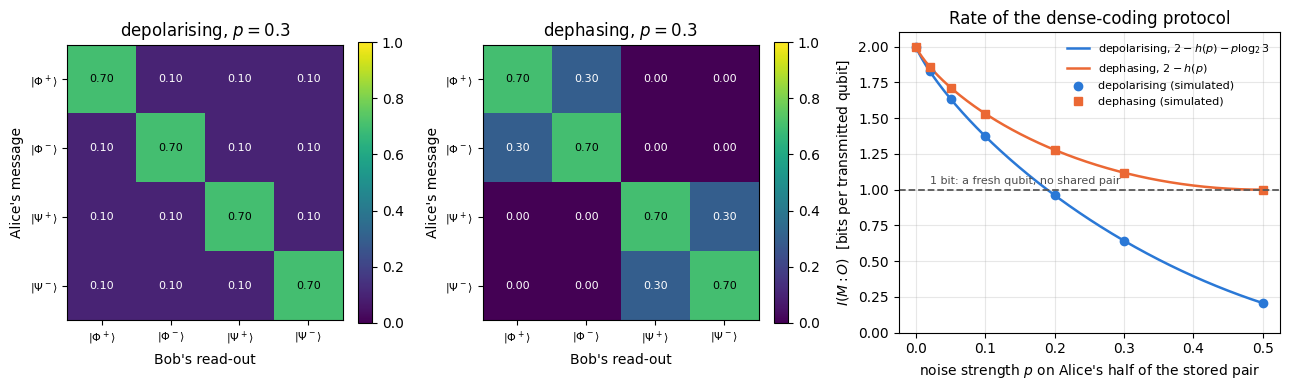

In [17]:
# ==============================================================================
# FIGURE: confusion matrices and transmission rate of noisy superdense coding
# ==============================================================================
fig = plt.figure(figsize=(13.0, 4.0))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.25])
P_SHOW = 0.30
for j, (name, kr) in enumerate((("depolarising", kraus_depolarizing), ("dephasing", kraus_dephasing))):
    ax = fig.add_subplot(gs[0, j])
    M = dense_confusion(kr, P_SHOW)
    im = ax.imshow(M, vmin=0, vmax=1, cmap="viridis")
    for a in range(4):
        for b in range(4):
            ax.text(b, a, f"{M[a, b]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if M[a, b] < 0.6 else "black")
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(BELL_TEX, fontsize=8); ax.set_yticklabels(BELL_TEX, fontsize=8)
    ax.set_xlabel("Bob's read-out"); ax.set_ylabel("Alice's message")
    ax.set_title(f"{name}, $p={P_SHOW}$"); ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)

ax = fig.add_subplot(gs[0, 2])
pfine = np.linspace(0, 0.5, 300)
ax.plot(pfine, 2 - binary_entropy(pfine) - pfine * np.log2(3), "-", color=PALETTE[0], lw=1.8,
        label=r"depolarising, $2-h(p)-p\log_2 3$")
ax.plot(pfine, 2 - binary_entropy(pfine), "-", color=PALETTE[1], lw=1.8, label=r"dephasing, $2-h(p)$")
ax.plot(P_GRID, res["depolarising"][0], MARKERS[0], color=PALETTE[0], ms=6, label="depolarising (simulated)")
ax.plot(P_GRID, res["dephasing"][0], MARKERS[1], color=PALETTE[1], ms=6, label="dephasing (simulated)")
ax.axhline(1.0, color="0.35", ls="--", lw=1.3)
ax.text(0.02, 1.04, "1 bit: a fresh qubit, no shared pair", fontsize=8, color="0.3")
ax.set_xlabel("noise strength $p$ on Alice's half of the stored pair")
ax.set_ylabel(r"$I(M:O)$  [bits per transmitted qubit]")
ax.set_title("Rate of the dense-coding protocol"); ax.legend(fontsize=8); ax.set_ylim(0, 2.1)
fig.tight_layout(); plt.show()

The two confusion matrices show which messages are confused. For **dephasing** the matrix is block-diagonal in the pairs
$\{\Phi^+,\Phi^-\}$ and $\{\Psi^+,\Psi^-\}$: a $Z$ error flips the phase bit and nothing else, so $\Phi$ is never mistaken for
$\Psi$ — the flip bit $m_2$ arrives untouched. For **depolarising** all three wrong messages receive the same weight $p/3$, because
$X$, $Y$ and $Z$ are equally likely and they flip $(0,1)$, $(1,1)$ and $(1,0)$ respectively.

The right panel adds the practical consequence: dense coding is worth its ebit only while $I>1$ bit, because Alice can always
discard the pair and send a *freshly prepared, noiseless* qubit carrying the bit in $\vert0\rangle$ or $\vert1\rangle$. This
fall-back is the reason the capacity of Section 14.2 is at least $\max(1,\,2-H(q))$. The dashed line is at $1$ bit **because the
noise in this model sits on the stored pair and not on the transmission**: if the same channel also acted on the travelling qubit, the
fall-back would be worth less, and under depolarising noise much less — a $Z$-basis bit is flipped by $X$ or $Y$, i.e. with
probability $2p/3$, so the bare qubit would deliver only $1-h(2p/3)=0.45$ bits at $p=0.19$. The dashed line therefore stands for
a fresh qubit sent through a clean channel.

The two channels behave very differently for a structural reason: under dephasing the flip bit $m_2$
is *never* corrupted, so $R_{\text{deph}}=2-h(p)$ can never fall below $1$ bit — the worst case is $p=1/2$, where the phase bit is
pure noise and exactly one clean bit survives. Under depolarising all four error patterns compete, and the rate does cross the line.
Let us locate the crossing by bisection and verify the claim about dephasing by scanning.

In [18]:
# ==============================================================================
# CHECKPOINT: at which noise level does dense coding stop beating a bare qubit (I = 1 bit)?
# ==============================================================================
def p_break_even(fun, lo=0.0, hi=0.75, iters=60):
    """Bisection for the p where the rate fun(p) crosses 1 bit (fun is decreasing on [lo,hi])."""
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if fun(mid) > 1.0 else (lo, mid)
    return 0.5 * (lo + hi)


p_dep = p_break_even(lambda p: 2 - binary_entropy(p) - p * np.log2(3))
M_dep = dense_confusion(kraus_depolarizing, p_dep)
print(f"depolarising: break-even at p = {p_dep:.4f}   (rate of the simulated device there: "
      f"{mutual_information_bits(M_dep):.6f} bits;  Eq. (13): "
      f"{dense_capacity_entropic(kraus_depolarizing, p_dep):.6f} bits)")

pscan = np.linspace(0.0, 1.0, 101)
I_dph = np.array([mutual_information_bits(dense_confusion(kraus_dephasing, float(p))) for p in pscan])
i_min = int(np.argmin(I_dph))
print(f"dephasing:    minimum of the measured rate over p in [0,1] is {I_dph[i_min]:.6f} bits "
      f"at p = {pscan[i_min]:.2f}  ->  dense coding NEVER falls below 1 bit under pure dephasing")
print(f"              (largest deviation from the formula 2 - h(p): "
      f"{np.max(np.abs(I_dph - (2 - binary_entropy(pscan)))):.1e})")
assert abs(mutual_information_bits(M_dep) - 1.0) < 1e-6
assert abs(I_dph[i_min] - 1.0) < 1e-9 and np.max(np.abs(I_dph - (2 - binary_entropy(pscan)))) < 1e-9

depolarising: break-even at p = 0.1893   (rate of the simulated device there: 1.000000 bits;  Eq. (13): 1.000000 bits)


dephasing:    minimum of the measured rate over p in [0,1] is 1.000000 bits at p = 0.50  ->  dense coding NEVER falls below 1 bit under pure dephasing
              (largest deviation from the formula 2 - h(p): 1.3e-15)


Under depolarising noise the simulated protocol crosses the one-bit line at the value printed above, and the exact confusion matrix
evaluated there returns $1.000000$ bits: the analytic break-even point of Eq. (12) and the simulated device agree. At that same $p$
the entropic formula Eq. (13) also returns $1$ bit, which says the same thing in the language of states: $S(\rho_{AB})=S(\rho_B)$,
the shared pair has exactly as much global entropy as Bob's half alone, and its coherent information has run out. Beyond that
point using the pair costs information; Alice should discard it and send a fresh qubit, which is why the *capacity* stays at
$1$ bit or above while the rate of this fixed protocol keeps falling. The pair is still entangled at the break-even
point — depolarising noise leaves it entangled up to $p=1/2$ — so "entangled" and "useful for dense coding" are different
thresholds. Under pure dephasing the scan confirms the structural argument: the measured rate dips to exactly $1$ bit at $p=1/2$
and rises again (a "dephasing" with $p>1/2$ is a deterministic $Z$ plus weaker noise), so the protocol is never worse than the
trivial one.

## 15. Shot statistics: dense coding as an actual experiment

Everything in Section 14 used exact probabilities. A device produces *samples*. Here we close the loop: `vmap` over shots, sample
Bob's read-out from the noisy state, build the empirical confusion matrix with binomial error bars, and compare with the exact one.
This is also a small lesson in how many shots a rate measurement costs.

In [19]:
# ==============================================================================
# STEP 11: sampled confusion matrix with error bars
# ==============================================================================
@partial(jax.jit, static_argnames=("shots",))
def sample_readout(key, probs, shots):
    """Draw `shots` read-out codes 0..3 from an exact probability vector (Gumbel-max categorical sampling)."""
    return jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)), shape=(shots,))


SHOTS_PER_MSG = 3000
P_SAMPLE = 0.20
M_exact = dense_confusion(kraus_depolarizing, P_SAMPLE)
keys = jax.random.split(jax.random.PRNGKey(7), 4)
M_hat = np.zeros((4, 4))
for i in range(4):
    draws = np.asarray(sample_readout(keys[i], jnp.asarray(M_exact[i]), SHOTS_PER_MSG))
    M_hat[i] = np.array([np.mean(draws == c) for c in range(4)])

E_hat = binom_err(M_hat, SHOTS_PER_MSG)
print(f"depolarising p = {P_SAMPLE}, {SHOTS_PER_MSG} shots per message\n")
print(f"{'message':>9s} | " + " ".join(f"{lab:>16s}" for lab in BELL_LABELS))
for i, lab in enumerate(BELL_LABELS):
    print(f"{lab:>9s} | " + " ".join(f"{M_hat[i, j]:.4f}+-{E_hat[i, j]:.4f}" for j in range(4)))
print("\nexact   | " + " ".join(f"{x:16.4f}" for x in M_exact[0]) + "   (first row)")
I_hat, I_exact = mutual_information_bits(M_hat), mutual_information_bits(M_exact)
pulls = np.abs(M_hat - M_exact) / np.maximum(E_hat, 1e-12)
print(f"\nmutual information: sampled {I_hat:.4f} bits   exact {I_exact:.4f} bits   "
      f"difference {abs(I_hat - I_exact):.4f}")
print(f"largest deviation of any entry from the exact value: {np.max(pulls):.2f} sigma")
assert np.max(pulls) < 5.0

# wrong control: the other common depolarising convention, rho -> (1-p) rho + p 1/2, i.e. X, Y, Z each with
# probability p/4 (error rate 3p/4).  The sampled matrix must reject it.
q_alt = np.array([1 - 3 * P_SAMPLE / 4] + [P_SAMPLE / 4] * 3)
M_alt = np.array([[q_alt[BELL_BITS.index((m[0] ^ o[0], m[1] ^ o[1]))] for o in BELL_BITS] for m in BELL_BITS])
pulls_alt = np.abs(M_hat - M_alt) / np.maximum(E_hat, 1e-12)
print(f"same data against the p/4 convention (error rate {3 * P_SAMPLE / 4:.2f}): largest deviation {np.max(pulls_alt):.1f} sigma")
assert np.max(pulls_alt) > 5.0

# how good is a single estimate of I?  Repeat the whole experiment R times with independent keys.
R_REP = 400
rep_keys = jax.random.split(jax.random.PRNGKey(8), R_REP * 4).reshape(R_REP, 4, 2)
draws_rep = np.asarray(jax.vmap(jax.vmap(lambda k, pr: sample_readout(k, pr, SHOTS_PER_MSG), in_axes=(0, 0)),
                                in_axes=(0, None))(rep_keys, jnp.asarray(M_exact)))      # (R, 4 messages, shots)
I_rep = np.array([mutual_information_bits(np.stack([np.bincount(d, minlength=4) / SHOTS_PER_MSG for d in rep]))
                  for rep in draws_rep])
bias, spread = I_rep.mean() - I_exact, I_rep.std(ddof=1)
print(f"{R_REP} repetitions: mean of the estimates - exact = {bias:+.4f} +- {spread / np.sqrt(R_REP):.4f} bits,  "
      f"spread of one estimate = {spread:.4f} bits")
assert abs(bias) < 0.25 * spread and 0.003 < spread < 0.05

depolarising p = 0.2, 3000 shots per message

  message |             Phi+             Phi-             Psi+             Psi-
     Phi+ | 0.8017+-0.0073 0.0623+-0.0044 0.0687+-0.0046 0.0673+-0.0046
     Phi- | 0.0663+-0.0045 0.7990+-0.0073 0.0660+-0.0045 0.0687+-0.0046
     Psi+ | 0.0643+-0.0045 0.0687+-0.0046 0.7940+-0.0074 0.0730+-0.0047
     Psi- | 0.0670+-0.0046 0.0707+-0.0047 0.0597+-0.0043 0.8027+-0.0073

exact   |           0.8000           0.0667           0.0667           0.0667   (first row)

mutual information: sampled 0.9590 bits   exact 0.9611 bits   difference 0.0020
largest deviation of any entry from the exact value: 1.62 sigma
same data against the p/4 convention (error rate 0.15): largest deviation 7.6 sigma


400 repetitions: mean of the estimates - exact = +0.0008 +- 0.0007 bits,  spread of one estimate = 0.0132 bits


Every entry of the sampled confusion matrix agrees with the exact one within a few standard errors, while the same data reject the
other depolarising convention (error rate $3p/4$ instead of $p$) by many standard errors, so the test can distinguish the two
conventions.

The single estimate of $I(M{:}O)$ from $4\times3000$ runs happens to land within a few thousandths of a bit of the exact value.
The repetitions show what to expect in general: one estimate scatters by about one hundredth of a bit, so the close agreement of
the first run is partly luck. The mutual information is also a *non-linear* function of the frequencies, so its plug-in estimate
is biased: each entropy estimate is too low by an amount of order $1/n_{\text{shots}}$, the conditional entropy (from $3000$ shots
per row) more so than the output entropy (from all $12\,000$), which makes $\hat I$ slightly too high on average. The printed
mean offset is of order $10^{-3}$ bits, comparable to its own standard error and far below the scatter of a single estimate. For an
experiment the scatter (a bootstrap interval, for instance) is therefore the number to quote.

## 16. Cost and scaling

All of this is cheap, and it is worth seeing why. The protocols involve $N=2$ or $N=4$ qubits, so a state vector has $2^N\le16$
complex numbers and a density tensor $4^N\le256$. The expensive-looking objects — the $16\times16$ projectors of the Bell
measurement, the $256\times256$ superoperator of a Kraus channel — are never built: `apply_gate` contracts a $2\times2$ or
$4\times4$ matrix into the chosen axes, and `apply_kraus_dm` sums over the Kraus index *inside* one einsum.

The interesting scaling question is the **shot** dimension. One shot of the swapping protocol is a fixed number of einsums on a
16-element tensor; `vmap` turns $n_{\text{shots}}$ of them into the same einsums on tensors with a leading batch axis, which XLA
executes as batched contractions. The cost is therefore linear in the number of shots with a very small
prefactor, and the compile time is paid once. Let us measure it.

In [20]:
# ==============================================================================
# BENCHMARK: compile time vs run time, and scaling with the number of shots
# ==============================================================================
def timed(fn, *args, repeats=3):
    """(first call incl. compilation, best of `repeats` further calls) in seconds."""
    t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); best = min(best, time.perf_counter() - t0)
    return first, best


shot_counts = [250, 1000, 4000, 16000]
print(f"{'shots':>7s} {'first call [ms]':>16s} {'best call [ms]':>15s} {'us per shot':>13s}")
for ns in shot_counts:
    f = jax.jit(jax.vmap(swap_one_shot))
    first, best = timed(f, jax.random.split(jax.random.PRNGKey(11), ns))
    print(f"{ns:7d} {first * 1e3:16.1f} {best * 1e3:15.2f} {best / ns * 1e6:13.2f}")
print("\n(The first call includes tracing and XLA compilation; it is paid once per shape.)")

  shots  first call [ms]  best call [ms]   us per shot


    250            257.8            0.54          2.16


   1000            299.7            1.31          1.31


   4000            283.3            5.02          1.26


  16000            238.2           16.53          1.03

(The first call includes tracing and XLA compilation; it is paid once per shape.)


The first call at each batch size is dominated by compilation; subsequent calls are much faster and the time per shot falls as the
batch grows, because the fixed overhead of a dispatch is amortised over more work. This is the standard JAX picture: *compile once,
batch as much as memory allows*.

> **Numerical practice.** Always report compile time and run time separately. In the table above the first call at the smallest
> batch takes several hundred times longer than the following ones, so a benchmark that times a single first call measures the
> compiler, and any comparison with an uncompiled alternative is biased against the compiled code.

## 17. Key takeaways

* **Equation (5) contains the protocol.** It rewrites two Bell pairs as a sum of four terms in which the *middle* pair and
  the *outer* pair carry the same Bell label. Measuring the middle pair therefore projects the outer pair — which never
  interacted — into a maximally entangled state, with probability $1/4$ per outcome. The flat distribution requires maximally
  mixed relay qubits; for weaker links ($a=0.8$) it becomes $0.34,0.34,0.16,0.16$, which the shot test confirmed.
* **Entanglement is consumed.** Two ebits go in (one per link), one ebit comes out across a longer distance, plus two
  classical bits of message. The measured negativity of the outer pair goes $0\to1/2$ *conditioned on the outcome*, and stays $0$
  when the outcome is discarded — no-signalling in a single number.
* **Feed-forward without branching.** `jnp.where` selects both the projector and the Pauli correction from traced outcomes, so a
  mid-circuit measurement plus a classical decision compiles into one XLA program and `vmap`s over shots. All 4000 simulated shots
  ended with fidelity $1$ to round-off, and the shot tests reject a permuted label map, a missing renormalisation and swapped
  correction bits.
* **Noise multiplies.** A Werner link of parameter $W$ is a Bell pair with a random Pauli error; swapping convolves the error
  distributions, and for isotropic noise this gives exactly $W_{\text{out}}=W_1W_2$, or
  $F_{\text{out}}=F_1F_2+(1-F_1)(1-F_2)/3$ for the fidelities, verified to $10^{-16}$ on the density tensor.
  A chain of $n$ links has $W^n$, loses entanglement once $W^n\le1/3$, and therefore needs **purification** interleaved with
  swapping — this is the content of the quantum-repeater proposal.
* **Superdense coding is the time-reverse of teleportation.** Encode with $X^{m_2}Z^{m_1}$, send one qubit, decode with a Bell
  measurement: two bits, error-free, measured as an exact identity confusion matrix. The travelling qubit alone is $\mathbb 1/2$
  for every message, and its Holevo $\chi$ is exactly $0$, so no measurement on it alone reveals the message, while Bob's two-qubit
  $\chi$ is exactly $2$ bits, saturating the Holevo bound for $d=4$.
* **A noisy pair turns dense coding into a classical additive-noise channel** on two bits, Eq. (11). Dephasing corrupts only the
  phase bit ($R=2-h(p)$, block-diagonal confusion matrix); depolarising corrupts all three wrong messages equally
  ($R=2-h(p)-p\log_23$). Both formulas were reproduced exactly by the simulated device.
* **The rate of a protocol and the capacity of a resource are different quantities.** Eq. (12) is the rate of *this* encoding and
  decoding, reached with classical block codes over many uses. It coincides with the unitary-encoding dense-coding capacity
  $\log_2 d_A+S(\rho_B)-S(\rho_{AB})$ of Eq. (13) for Bell-diagonal pairs (verified to $10^{-14}$), so the protocol is optimal
  among unitary encodings; but Alice can always discard the pair and send a fresh qubit, so the capacity with general encodings,
  Eq. (14), never falls below $1$ bit, while the rate does, at $p=0.1893$ for depolarising noise.
* **Method lesson.** Every analytic claim in this notebook was checked by a *structurally different* computation: pure-state
  projection against density-tensor Kraus evolution, group convolution against explicit partial transposes, exact probabilities
  against sampled frequencies with binomial error bars. Agreement across such different routes is what makes a simulator
  trustworthy.

## 18. Exercises

1. ★ **The other correction.** Section 4 derives Bob's correction on qubit $3$ from Eq. (4). Show that Alice can correct on qubit
   $0$ instead, using Eq. (3) alone and no transpose, and verify it by editing `swap_one_shot`. Does the fidelity change? Then
   work out what happens if *both* apply the correction: compute $(U_k\otimes U_k)\vert B_k\rangle$ with Eq. (4), predict the
   fidelity with $\vert\Phi^+\rangle$ for each of the four outcomes, and check the prediction against a run of 4000 shots.
2. ★ **A different pair of links.** Redo Section 6 starting from $\vert\Psi^-\rangle_{01}\otimes\vert\Phi^+\rangle_{23}$. Predict
   the new outcome-to-Bell-state dictionary from Eq. (3) *before* running the code, then check it. (Hint: $\vert\Psi^-\rangle$ is
   $\vert\Phi^+\rangle$ with an $XZ$ already applied.)
3. ★★ **Three-link chain in one go (extend the code).** Write a function that builds $n$ Bell pairs on $2n$ qubits, performs the
   $n-1$ Bell measurements on the inner pairs in a single `jit`-compiled function with feed-forward, and returns the fidelity of
   the end pair. Check for $n=3$ ($6$ qubits) that the fidelity is $1$ in the noiseless case, and compare the run time with the
   iterative density-tensor route of Section 11.
4. ★★ **Asymmetric links (physics).** With $W_1$ fixed at $0.9$, how good must the second link be for the swapped pair to stay
   entangled? Solve $W_1W_2>1/3$ by hand and confirm with `swap_dm`. Then: given a *total* noise budget $W_1W_2=\text{const}$, does
   it matter how it is distributed between the links?
5. ★★ **Dense coding with a Werner pair (extend the code).** Replace the perfect $\vert\Phi^+\rangle$ in `dense_confusion` by
   $\rho_W$ of Eq. (7). Predict the confusion matrix from Eq. (8) and Eq. (11) before running it, then measure the rate
   $I(M{:}O)$ as a function of $W$ and find the $W$ at which it drops to $1$ bit. Compare with the entanglement
   threshold $W=1/3$: are they the same number? Should they be? (Check your answer against Eq. (13): the condition is
   $S(\rho_{AB})=S(\rho_B)=1$ bit.)
6. ★★ **Amplitude damping (physics).** Repeat Section 14 with `kraus_amplitude_damping(\gamma)`. This channel is *not* a random
   Pauli — it is not even unital — so there is no reason to expect Eq. (11) to survive. Measure the confusion matrix and find out:
   it *is* still of additive-noise form, with an error distribution that is no longer isotropic. Derive it by hand (apply the two
   Kraus operators to $\vert\Phi^+\rangle\langle\Phi^+\vert$ and read off the four Bell populations; you should find
   $q=\big(\tfrac14(1+\sqrt{1-\gamma})^2,\ \tfrac14(1-\sqrt{1-\gamma})^2,\ \tfrac\gamma4,\ \tfrac\gamma4\big)$), and explain
   why the additive structure survives even though the channel is not a Pauli channel. (Hint: conjugating amplitude damping by
   $X$ turns it into amplitude *raising*, which has the same Bell populations.) Then compute $I$ for several non-uniform priors
   and decide whether any of them beats the uniform one — this is the question the Blahut–Arimoto algorithm answers in general.
7. ★★★ **Purification (extend the code).** Implement one round of the recurrence purification protocol: take two copies of a
   Werner state with parameter $W$ (four qubits), apply a bilateral $\mathrm{CNOT}$ (each party from their half of the first pair
   to their half of the second), measure the target pair in the $Z$ basis, keep the source pair only if the two results agree.
   Measure the success probability and the output state. It is Bell-diagonal but no longer isotropic, so define $W'$ from its
   fidelity, $W'=(4F'-1)/3$, or re-twirl it back to Werner form. Plot $W'$ versus $W$, identify the fixed point (you should find
   $F'=F$ at $F=1/2$, i.e. exactly at the entanglement threshold $W=1/3$), and use it to explain why purification $+$ swapping
   beats pure swapping over a long chain. [Notebook 54](../ch14_quantum_communication_and_cryptography/54_noisy_entanglement_distillation_repeaters_certification.ipynb),
   Section 7, derives this protocol and runs it in a repeater chain.
8. ★★★ **Swapping with imperfect measurement (physics).** Model a relay whose Bell measurement occasionally reports the wrong
   outcome (probability $\varepsilon$ of a random other label). Derive the resulting end-to-end state, show that it is again
   Werner-like, and find the combined condition on $(W,\varepsilon)$ for the chain of $n$ links to remain entangled.
9. ★★★ **General encodings (physics).** Eq. (14) minimises $S\big((\Lambda\otimes\mathbb 1)\rho_{AB}\big)$ over all channels
   $\Lambda$ on Alice's qubit. Parametrise $\Lambda$ by four $2\times2$ Kraus operators obtained from a random $8\times2$ isometry
   (QR decomposition of a complex Gaussian matrix), minimise the entropy with `scipy.optimize.minimize` from many random starts,
   and do this for the depolarised pair at $p=0.1,\ 0.3,\ 0.5$ and the dephased pair at $p=0.3$. Compare the minimum with
   $\min\big(1,H(q)\big)$, the value reached by the identity channel and by the channel that prepares a pure state. Does any other
   channel do better? What does your answer imply for the single-copy capacity $C^{(1)}_{\text{dc}}$ of these states?

## References

* M. Żukowski, A. Zeilinger, M. A. Horne and A. K. Ekert, *"Event-ready-detectors" Bell experiment via entanglement swapping*,
  Phys. Rev. Lett. **71**, 4287 (1993) — the original entanglement-swapping proposal.
* J.-W. Pan, D. Bouwmeester, H. Weinfurter and A. Zeilinger, *Experimental entanglement swapping: entangling photons that never
  interacted*, Phys. Rev. Lett. **80**, 3891 (1998) — the experiment.
* C. H. Bennett and S. J. Wiesner, *Communication via one- and two-particle operators on Einstein-Podolsky-Rosen states*,
  Phys. Rev. Lett. **69**, 2881 (1992) — superdense coding.
* K. Mattle, H. Weinfurter, P. G. Kwiat and A. Zeilinger, *Dense coding in experimental quantum communication*,
  Phys. Rev. Lett. **76**, 4656 (1996) — the experimental demonstration.
* C. H. Bennett, G. Brassard, C. Crépeau, R. Jozsa, A. Peres and W. K. Wootters, *Teleporting an unknown quantum state via dual
  classical and Einstein-Podolsky-Rosen channels*, Phys. Rev. Lett. **70**, 1895 (1993) — the dual protocol of Section 12.3.
* H.-J. Briegel, W. Dür, J. I. Cirac and P. Zoller, *Quantum repeaters: the role of imperfect local operations in quantum
  communication*, Phys. Rev. Lett. **81**, 5932 (1998) — nested swapping and purification, Section 11.
* A. S. Holevo, *Bounds for the quantity of information transmitted by a quantum communication channel*, Problems of Information
  Transmission **9**(3), 177–183 (1973) — the bound of Section 13.
* T. Hiroshima, *Optimal dense coding with mixed state entanglement*, J. Phys. A: Math. Gen. **34**, 6907 (2001);
  G. Bowen, *Classical information capacity of superdense coding*, Phys. Rev. A **63**, 022302 (2001) — the dense-coding capacity
  $\log_2d_A+S(\rho_B)-S(\rho_{AB})$ for unitary encodings, Eq. (13).
* D. Bruß, G. M. D'Ariano, M. Lewenstein, C. Macchiavello, A. Sen(De) and U. Sen, *Distributed quantum dense coding*,
  Phys. Rev. Lett. **93**, 210501 (2004) — the same formula for $d_A\ne d_B$ and for several senders.
* M. Horodecki, P. Horodecki, R. Horodecki, D. Leung and B. Terhal, *Classical capacity of a noiseless quantum channel assisted by
  noisy entanglement*, Quantum Inf. Comput. **1**(3), 70 (2001) — the capacity when an arbitrary amount of noisy entanglement may
  be used per channel use.
* M. Horodecki and M. Piani, *On quantum advantage in dense coding*, J. Phys. A: Math. Theor. **45**, 105306 (2012) — general
  encoding operations; the single-copy capacity Eq. (14), with the minimisation over Alice's pre-processing channel.
* A. Winter, *Scalable programmable quantum gates and a new aspect of the additivity problem for the classical capacity of quantum
  channels*, J. Math. Phys. **43**, 4341 (2002) — noisy dense coding with general encodings and the associated additivity
  problem.
* R. F. Werner, *Quantum states with Einstein-Podolsky-Rosen correlations admitting a hidden-variable model*,
  Phys. Rev. A **40**, 4277 (1989) — Werner states.
* A. Peres, *Separability criterion for density matrices*, Phys. Rev. Lett. **77**, 1413 (1996); M. Horodecki, P. Horodecki and
  R. Horodecki, *Separability of mixed states: necessary and sufficient conditions*, Phys. Lett. A **223**, 1 (1996) — the PPT
  criterion behind the negativity.
* G. Vidal and R. F. Werner, *Computable measure of entanglement*, Phys. Rev. A **65**, 032314 (2002) — negativity and logarithmic
  negativity.
* W. K. Wootters, *Entanglement of formation of an arbitrary state of two qubits*, Phys. Rev. Lett. **80**, 2245 (1998) —
  concurrence.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) —
  Chapters 2, 8 and 12 cover Bell measurements, channels, the Holevo bound and both protocols.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/